In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.spike_detection import *
from utils.preprocess_neural import *


import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess
import shutil
import pickle
import glob
from utils.GRC_helpers import *

%matplotlib widget


In [2]:
#data_folder = '../data/CKII_pAce38_PX_20251126'
data_folder = '../data/CKII_pAce21_PR_20250806'
#data_folder = '../data/CKII_pAce45_PX_20260118'


# turn data_folder into absolute path
data_folder = os.path.abspath(data_folder)
print(f'Loading data from: {data_folder}')

data_name = os.path.basename(data_folder)
figure_save_folder = f'../figures/{data_name}'
figure_save_folder = os.path.abspath(figure_save_folder)
print(f'Figures will be saved to: {figure_save_folder}')
if not os.path.exists(figure_save_folder):
    os.makedirs(figure_save_folder)

Loading data from: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce21_PR_20250806
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pAce21_PR_20250806


In [3]:
# load merged data 

merged_data_path_CS = os.path.join(data_folder, 'merged_aligned_data_CS.pkl')
with open(merged_data_path_CS, 'rb') as f:
    loaded_merged_data_CS = pickle.load(f)
    traces = loaded_merged_data_CS['traces']
    spikes = loaded_merged_data_CS['spikes']
    speed = loaded_merged_data_CS['speed']
    ts_neural = loaded_merged_data_CS['ts_neural']
    x_neural = loaded_merged_data_CS['x_neural']
    y_neural = loaded_merged_data_CS['y_neural']
    hd_angles_neural = loaded_merged_data_CS['hd_angles_neural']
    weights_all = loaded_merged_data_CS['weights_all']
    mean_images = loaded_merged_data_CS['mean_images']
    frame_rate = loaded_merged_data_CS['frame_rate']
    frame_width = loaded_merged_data_CS['frame_width']
    frame_height = loaded_merged_data_CS['frame_height']
    subfolders = loaded_merged_data_CS['subfolders']
    complex_bursts_dicts = loaded_merged_data_CS['complex_bursts_dicts']
    refined_SS = loaded_merged_data_CS['refined_SS']
    all_CS_spikes = loaded_merged_data_CS['all_CS_spikes']
    all_spikes = loaded_merged_data_CS['all_spikes']
    spike_heights_interpolated = loaded_merged_data_CS['spike_heights_interpolated']
    SNR_interpolated = loaded_merged_data_CS['SNR_interpolated']    
    session_start_frames = loaded_merged_data_CS['session_start_frames']
    traces_SNR_interpolated = loaded_merged_data_CS['traces_SNR_interpolated']
    Vm_SNR_interpolated = loaded_merged_data_CS['Vm_SNR_interpolated']
    burst_metrics = loaded_merged_data_CS['burst_metrics']

print(f"Loaded data from {merged_data_path_CS}")



Loaded data from /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce21_PR_20250806/merged_aligned_data_CS.pkl


In [4]:
# Optional: Remove bad SNR segments
spikes = all_spikes.copy()
traces = traces_SNR_interpolated
Vms = Vm_SNR_interpolated

SNR_threshold = 3.5
bad_masks = []

# Now for each cell: remove spikes and make traces and Vms NaN where its SNR_interpolated < SNR_threshold
for cell_idx in range(len(spikes)):
    snr_vals = np.asarray(SNR_interpolated[cell_idx])
    if snr_vals.ndim == 0:
        continue
    bad_mask = snr_vals < SNR_threshold
    bad_masks.append(bad_mask)
    if not np.any(bad_mask):
        continue

    traces[cell_idx][bad_mask] = np.nan
    Vms[cell_idx][bad_mask] = np.nan

    def _filter_spikes(spk_arr, bad_mask_local):
        spk_arr = np.asarray(spk_arr, dtype=np.int64)
        if spk_arr.size == 0:
            return spk_arr
        spk_arr = spk_arr[(spk_arr >= 0) & (spk_arr < bad_mask_local.shape[0])]
        return spk_arr[~bad_mask_local[spk_arr]]

    spikes[cell_idx] = _filter_spikes(spikes[cell_idx], bad_mask)
    all_CS_spikes[cell_idx] = _filter_spikes(all_CS_spikes[cell_idx], bad_mask)
    refined_SS[cell_idx] = _filter_spikes(refined_SS[cell_idx], bad_mask)

    print(f'Cell {cell_idx}: removed {np.sum(bad_mask)} bad SNR frames, spikes reduced from {len(loaded_merged_data_CS["all_spikes"][cell_idx])} to {len(spikes[cell_idx])}')

bad_masks = np.array(bad_masks)

# Animal + Cage

In [5]:
# avi_matches = glob.glob(os.path.join(subfolders[0], "*.avi"))
# if not avi_matches:
#     raise FileNotFoundError(f"No .avi files found in {subfolders[0]}")
# behav_video_path = sorted(avi_matches)[0]

# fig, ax = plt.subplots(figsize=(3,3))
# behav_img = plot_annotated_behavior_frame(behav_video_path, 1200, ax)
# out_path = os.path.join(
#     figure_save_folder,
#     "behavior_frame1200_annotated.svg"
# )
# plt.rcParams["svg.fonttype"] = "none" 
# fig.savefig(out_path, dpi=300)
# print(f"Saved to {out_path}")

# plt.show()

# Speed Epochs Plotting

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pAce21_PR_20250806/speed_with_moving_epochs_speed3.svg


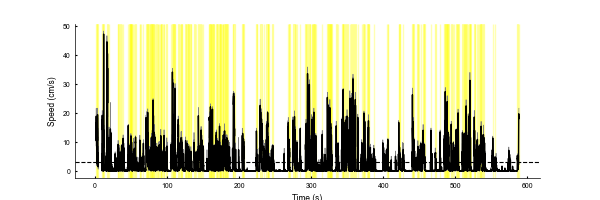

In [6]:
fig, ax = plt.subplots(figsize=(6, 2))

### Works for pAce38
# speed_threshold = 4
# min_duration_s = 0.25
# merge_gap_s = 0.2
# kernel_size = 51

### Works for pAce21 2025-08-06
speed_threshold = 3
min_duration_s = 0.25
merge_gap_s = 0.
kernel_size = 51
_, _, _ = plot_speed_with_moving_epochs(speed, frame_rate, speed_threshold=speed_threshold, kernel_size=kernel_size, filter_type="boxcar", ax=ax, min_duration_s=min_duration_s, merge_gap_s=merge_gap_s)

out_path = os.path.join(
    figure_save_folder,
    f"speed_with_moving_epochs_speed{speed_threshold}.svg",
)
plt.rcParams["svg.fonttype"] = "none"
fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")


# Spike maps, all cells

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pAce21_PR_20250806/trajectory_with_spikes_speed3.svg


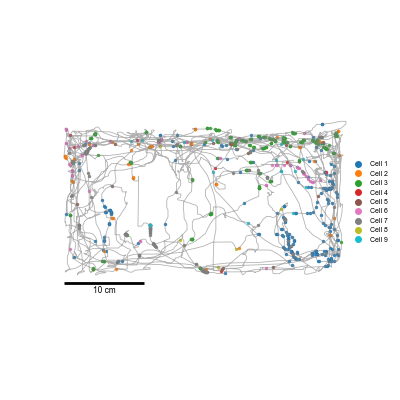

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_trajectory_with_spikes(
    x_neural, y_neural, spikes, speed, frame_rate,
    ax=ax,
    kernel_size=kernel_size, filter_type="boxcar",
    speed_threshold=speed_threshold, min_duration_s=min_duration_s, merge_gap_s=merge_gap_s
)

out_path = os.path.join(
    figure_save_folder,
    f"trajectory_with_spikes_speed{speed_threshold}.svg"
)
plt.rcParams["svg.fonttype"] = "none" 
fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")


# Spatial heatmaps for all cells

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_39842/1259728136.py:73: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=300)


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pAce21_PR_20250806/place_cell_single_moving_speed3.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  self.figure.savefig(buf, format='png', dpi='figure')


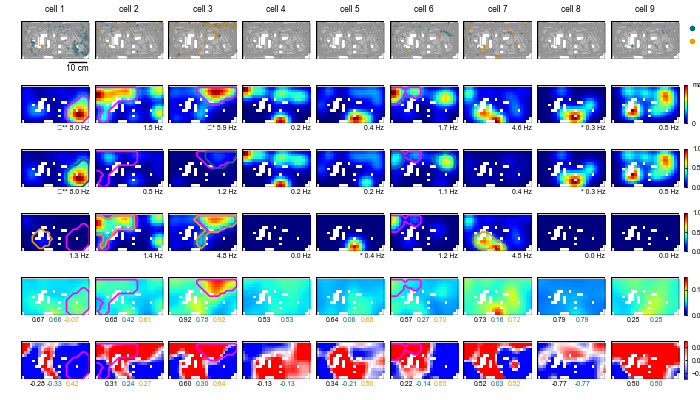

In [8]:
place_field_threshold = 0.3
min_field_bins = 20
max_field_area_ratio = 2/3
theta_freqs = [4, 8]
slow_freqs = 2

# Custom cell order: specify which cells to plot and in what order
# Use original 0-indexed cell indices; set to None to use all cells in order

# [0, 2, 3, 6, 8, 1, 5, 4, 7] for pAce38

cell_order = None

if cell_order is None:
    cell_order = list(range(len(spikes)))

# Initialize PC_output_all with None for all cells, indexed by original cell index
PC_output_all = [None] * len(spikes)

num_cols = len(cell_order)
fig, axes = plt.subplots(6, num_cols, figsize=(7,4), sharex=True, sharey=True)

for col_idx, cell_idx in enumerate(cell_order):
    out = analyze_place_cell_single_moving(
        x_neural, y_neural, spikes, speed, frame_rate,
        cell_idx=cell_idx,
        axes=axes[:, col_idx],
        place_field_threshold = place_field_threshold,
        min_field_bins = min_field_bins,
        speed_threshold=speed_threshold,
        kernel_size=kernel_size,
        filter_type="boxcar",
        min_duration_s=min_duration_s, merge_gap_s=merge_gap_s,
        plot_pf_contours=True,
        max_field_area_ratio=max_field_area_ratio,
        bad_timepoints=bad_masks[cell_idx] if bad_masks is not None else None,
        num_shuffles=1000,
        random_seed=42,
        plot_sub=True,
        traces=traces,
        theta_freqs=theta_freqs,
        slow_freqs=slow_freqs,
        separate_spikes=True,
        refined_SS=refined_SS,
        all_CS_spikes=all_CS_spikes,
        display_cell_num=cell_idx + 1,  # Display original cell number (1-indexed)
        is_first_column=(col_idx == 0),
        is_last_column=(col_idx == num_cols - 1),
        min_occupancy_s=0.001,
        occ_smooth_sigma=2.0,
    )
    # Store result at the original cell index, not the display order
    PC_output_all[cell_idx] = out

# Set theta Vm color range for the second to last row
for ax in axes[-2, :]:
    if ax.images:
        ax.images[0].set_clim(0, 0.15)

# Set slow Vm color range for the last row
for ax in axes[-1, :]:
    if ax.images:
        ax.images[0].set_clim(-0.015, 0.015)

plt.subplots_adjust(left=0.03, right=0.97, top=0.98, bottom=0.02, wspace=0.08, hspace=0.01)

out_path = os.path.join(
    figure_save_folder,
    f"place_cell_single_moving_speed{speed_threshold}.svg"
)
plt.rcParams["svg.fonttype"] = "none"  # keep text editable in SVG

fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")

# Theta Vm

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


theta_run_in = []
theta_run_out = []
theta_rest_in = []
theta_rest_out = []

for i in range(len(spikes)):
    # out_sub = get_subthreshold_activity(
    #     traces, all_spikes, all_CS_spikes, refined_SS, complex_bursts_dicts,
    #     spike_heights_interpolated, ts_neural, frame_rate,
    #     idx=i, mask_duration=1000
    # )

    out_theta = compute_theta_amp_by_pf(
        x_neural, y_neural, speed, frame_rate,
        spikes, trace=Vms[i],
        cell_idx=i,
        analysis = PC_output_all[i],
        speed_threshold=speed_threshold,
        kernel_size=kernel_size, filter_type="boxcar",
        min_duration_s=min_duration_s, merge_gap_s=merge_gap_s,
        theta_freqs=(4,8),
        bad_timepoints=bad_masks[i] if bad_masks is not None else None,
    )

    if not out_theta["is_place_cell"]:
        continue

    ta = out_theta["theta_amp"]
    theta_run_in.append(ta["run_in"])
    theta_run_out.append(ta["run_out"])
    theta_rest_in.append(ta["rest_in"])
    theta_rest_out.append(ta["rest_out"])

theta_run_in = np.array(theta_run_in, dtype=float)
theta_run_out = np.array(theta_run_out, dtype=float)
theta_rest_in = np.array(theta_rest_in, dtype=float)
theta_rest_out = np.array(theta_rest_out, dtype=float)


print('Included place cells:', len(theta_run_in))
output_dir = data_folder
os.makedirs(output_dir, exist_ok=True)


out_path = os.path.join(
    output_dir,
    f"theta_amp_speed{speed_threshold}.npz"
)
np.savez(
    out_path,
    theta_run_in=theta_run_in,
    theta_run_out=theta_run_out,
    theta_rest_in=theta_rest_in,
    theta_rest_out=theta_rest_out,
)
print(f"Saved to {out_path}")



Included place cells: 7
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/theta_amp_speed3.npz


Locomotion theta amp (paired t-test): n=7, stat=3.42, p=0.0141, shapiro_p=0.776
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/ThetaAmp_in_out_PF_run.svg


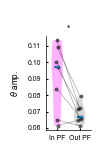

Quiet theta amp (paired t-test): n=7, stat=1.23, p=0.266, shapiro_p=0.141
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/ThetaAmp_in_out_PF_rest.svg


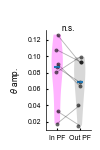

In [23]:
from scipy import stats
import numpy as np

def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

panel_w = 1.0
panel_h = 1.5
xlim = (0.5, 2.5)

def _global_ylim(arrays, pad_frac=0.08):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = np.nanmin(merged)
    y_max = np.nanmax(merged)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

theta_ylim = _global_ylim([
    theta_run_in,
    theta_run_out,
    theta_rest_in,
    theta_rest_out,
])

state_specs = [
    ('run', 'Locomotion', np.asarray(theta_run_in, dtype=float), np.asarray(theta_run_out, dtype=float)),
    ('rest', 'Quiet', np.asarray(theta_rest_in, dtype=float), np.asarray(theta_rest_out, dtype=float)),
]

for state_key, state_label, vals_in, vals_out in state_specs:
    fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h), sharex=True, sharey=True)
    plot_data = []
    for vals in [vals_in, vals_out]:
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            finite = np.array([np.nan])
        plot_data.append(finite)

    parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
    for body in parts['bodies']:
        body.set_alpha(0.3)
    if len(parts['bodies']) >= 2:
        parts['bodies'][0].set_facecolor('magenta')
        parts['bodies'][1].set_facecolor('gray')
        parts['bodies'][0].set_edgecolor('none')
        parts['bodies'][1].set_edgecolor('none')

    n_pairs = min(len(vals_in), len(vals_out))
    for i in range(n_pairs):
        if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
            ax.plot(
                [1, 2],
                [vals_in[i], vals_out[i]],
                color='black',
                alpha=0.3,
                linewidth=0.6,
            )

    rng = np.random.default_rng(0)
    for idx, vals in enumerate([vals_in, vals_out], start=1):
        finite_mask = np.isfinite(vals)
        if not np.any(finite_mask):
            continue
        jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
        xs = idx + jitter
        ax.scatter(
            xs,
            vals[finite_mask],
            s=8,
            color='black',
            alpha=0.6,
            linewidths=0,
        )

    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
    sig_label = _sig_label(p_val)
    if np.isfinite(p_val):
        print(
            f"{state_label} theta amp ({test_name}): n={n_valid}, "
            f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
        )
    else:
        print(f"{state_label} theta amp: n={n_valid} (insufficient valid pairs)")
    if sig_label:
        y_vals = np.concatenate([vals_in[np.isfinite(vals_in)], vals_out[np.isfinite(vals_out)]])
        if y_vals.size > 0:
            y_max = np.nanmax(y_vals)
            y_min = np.nanmin(y_vals)
            y_span = y_max - y_min if y_max != y_min else 1.0
            y_off = 0.08 * y_span
            y_star = y_max + y_off
            if theta_ylim is not None:
                y0, y1 = theta_ylim
                y_span_global = y1 - y0 if y1 != y0 else 1.0
                y_star = min(y_star, y1 - 0.05 * y_span_global)
            ax.text(
                1.5,
                y_star,
                sig_label,
                ha='center',
                va='bottom',
                fontsize=6,
                fontname='Arial',
            )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        ['In PF', 'Out PF'],
        fontsize=5,
        fontname='Arial',
    )
    ax.set_ylabel(r'$\theta$ amp.', fontsize=6, fontname='Arial')
    ax.tick_params(labelsize=5)
    ax.set_xlim(*xlim)
    # if theta_ylim is not None:
    #     ax.set_ylim(*theta_ylim)
    for label in list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # fig.suptitle(
    #     f"$\theta$ amplitude - {state_label}",
    #     fontsize=6,
    #     fontname='Arial',
    # )
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    theta_violin_out_path = os.path.join(
        figure_save_folder,
        f"ThetaAmp_in_out_PF_{state_key}.svg",
    )
    fig.savefig(theta_violin_out_path, dpi=300)
    print(f"Saved to {theta_violin_out_path}")
    plt.show()



Included cells: 9
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/theta_amp_state_speed3.npz
State theta amp (paired t-test): n=9, stat=-1.99, p=0.0816, shapiro_p=0.158
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/ThetaAmp_state.svg


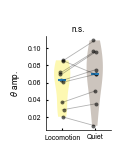

In [24]:
# Theta amplitude by behavioral state (INs, no place field)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


theta_run = []
theta_rest = []

for i in range(len(spikes)):
    # out_sub = get_subthreshold_activity(
    #     traces, all_spikes, all_CS_spikes, refined_SS, complex_bursts_dicts,
    #     spike_heights_interpolated, ts_neural, frame_rate,
    #     idx=i, mask_duration=1000
    # )

    out_theta = compute_theta_amp_by_state(
        speed,
        frame_rate,
        trace=Vms[i],
        cell_idx=i,
        kernel_size=kernel_size,
        filter_type='boxcar',
        speed_threshold=speed_threshold,
        min_duration_s=min_duration_s,
        merge_gap_s=merge_gap_s,
        theta_freqs=(4, 8),
        bad_timepoints=bad_masks[i] if bad_masks is not None else None,
    )

    ta = out_theta['theta_amp']
    theta_run.append(ta['run'])
    theta_rest.append(ta['rest'])

theta_run = np.array(theta_run, dtype=float)
theta_rest = np.array(theta_rest, dtype=float)

print('Included cells:', len(theta_run))

out_path = os.path.join(
    data_folder,
    f'theta_amp_state_speed{speed_threshold}.npz'
)
np.savez(
    out_path,
    theta_run=theta_run,
    theta_rest=theta_rest,
)
print(f'Saved to {out_path}')

def _paired_test(vals_a, vals_b):
    vals_a = np.asarray(vals_a, dtype=float)
    vals_b = np.asarray(vals_b, dtype=float)
    n_pairs = min(len(vals_a), len(vals_b))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_a = vals_a[:n_pairs]
    paired_b = vals_b[:n_pairs]
    valid = np.isfinite(paired_a) & np.isfinite(paired_b)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_a[valid] - paired_b[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_a[valid], paired_b[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_a[valid], paired_b[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.5), sharex=True, sharey=True)
plot_data = []
for vals in [theta_run, theta_rest]:
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        finite = np.array([np.nan])
    plot_data.append(finite)

run_color = "#f9e800ff"
rest_color = "#563c25"


parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
for body in parts['bodies']:
    body.set_alpha(0.3)
if len(parts['bodies']) >= 2:
    parts['bodies'][0].set_facecolor(run_color)
    parts['bodies'][1].set_facecolor(rest_color)
    parts['bodies'][0].set_edgecolor('none')
    parts['bodies'][1].set_edgecolor('none')

n_pairs = min(len(theta_run), len(theta_rest))
for i in range(n_pairs):
    if np.isfinite(theta_run[i]) and np.isfinite(theta_rest[i]):
        ax.plot([1, 2], [theta_run[i], theta_rest[i]], color='black', alpha=0.3, linewidth=0.6)

rng = np.random.default_rng(0)
for idx, vals in enumerate([theta_run, theta_rest], start=1):
    finite_mask = np.isfinite(vals)
    if not np.any(finite_mask):
        continue
    jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
    xs = idx + jitter
    ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.6, linewidths=0)

p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(theta_run, theta_rest)
sig_label = _sig_label(p_val)
if np.isfinite(p_val):
    print(
        f'State theta amp ({test_name}): n={n_valid}, stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}'
    )
else:
    print(f'State theta amp: n={n_valid} (insufficient valid pairs)')

if sig_label:
    y_vals = np.concatenate([theta_run[np.isfinite(theta_run)], theta_rest[np.isfinite(theta_rest)]])
    if y_vals.size > 0:
        y_max = np.nanmax(y_vals)
        y_min = np.nanmin(y_vals)
        y_span = y_max - y_min if y_max != y_min else 1.0
        y_star = y_max + 0.08 * y_span
        ax.text(1.5, y_star, sig_label, ha='center', va='bottom', fontsize=6, fontname='Arial')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Locomotion', 'Quiet'], fontsize=5, fontname='Arial')
ax.set_ylabel(r'$\theta$ amp.', fontsize=6, fontname='Arial')
ax.tick_params(labelsize=5)
ax.set_xlim(0.5, 2.5)
for label in list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#fig.suptitle('$\theta$ amplitude - state', fontsize=6, fontname='Arial')
plt.tight_layout(rect=[0, 0, 1, 0.9])
theta_violin_out_path = os.path.join(figure_save_folder, 'ThetaAmp_state.svg')
fig.savefig(theta_violin_out_path, dpi=300)
print(f'Saved to {theta_violin_out_path}')
plt.show()


# PSD

In [25]:
# # PSD by behavioral state (moving vs resting) with fixed-length chunks

# max_freq = 100

# run_color = "#f9e800ff"
# rest_color = "#563c25"

# psd_run_list = []
# psd_rest_list = []
# freqs = None

# figure_save_folder_psd = os.path.join(figure_save_folder, 'PSD_by_state_all_cells')
# if not os.path.exists(figure_save_folder_psd):
#     os.makedirs(figure_save_folder_psd)

# for cell_idx in range(len(Vms)):

#     out_psd = compute_psd_by_state(
#         speed,
#         frame_rate,
#         trace=Vms[i],
#         cell_idx=i,
#         bad_timepoints=(bad_masks[i] if bad_masks is not None else None),
#         kernel_size=kernel_size,
#         filter_type='boxcar',
#         speed_threshold=speed_threshold,
#         min_duration_s=min_duration_s,
#         merge_gap_s=merge_gap_s,
#         chunk_s=4.0,
#         nperseg_s=2.0,
#         noverlap_frac=0.5,
#     )

#     if out_psd['freqs'] is None or out_psd['psd_run'] is None or out_psd['psd_rest'] is None:
#         continue

#     if freqs is None:
#         freqs = out_psd['freqs']
#     freq_mask = (freqs > 0) & (freqs <= max_freq)
#     freqs_plot = freqs[freq_mask]

#     psd_run = out_psd['psd_run'][freq_mask]
#     psd_rest = out_psd['psd_rest'][freq_mask]

#     psd_run_list.append(psd_run)
#     psd_rest_list.append(psd_rest)

#     # Per-cell PSD plot
#     fig, ax = plt.subplots(1, 1, figsize=(2, 2))
#     ax.plot(freqs_plot, psd_run, color=run_color, linewidth=0.8, label='Locomotion')
#     ax.plot(freqs_plot, psd_rest, color=rest_color, linewidth=0.8, label='Quiet')
#     ax.set_xscale('log', base=2)
#     ax.set_xlim(1, max_freq)
#     ticks = [1, 2, 4, 8, 16, 32, 64, 100]
#     ticks = [t for t in ticks if t <= max_freq]
#     ax.set_xticks(ticks)
#     ax.set_xticklabels([str(t) for t in ticks])
#     ax.set_xlabel('Frequency (Hz)')
#     ax.set_ylabel('PSD')
#     ax.legend(frameon=False, fontsize=6)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     plt.tight_layout()
#     out_path = os.path.join(figure_save_folder_psd, f'PSD_state_cell{i}.svg')
#     fig.savefig(out_path, dpi=300)
#     #plt.close(fig)

# if psd_run_list and psd_rest_list:
#     freqs_plot = freqs[(freqs > 0) & (freqs <= max_freq)]
#     psd_run_mean = np.nanmean(np.array(psd_run_list), axis=0)
#     psd_run_sem = np.nanstd(np.array(psd_run_list), axis=0) / np.sqrt(len(psd_run_list))
#     psd_rest_mean = np.nanmean(np.array(psd_rest_list), axis=0)
#     # Save pooled PSD arrays for cross-FOV pooling
#     npz_out = os.path.join(data_folder, f'psd_state_speed{speed_threshold}.npz')
#     np.savez(
#         npz_out,
#         freqs=freqs_plot,
#         psd_run=psd_run_mean,
#         psd_rest=psd_rest_mean,
#         psd_run_cells=np.array(psd_run_list),
#         psd_rest_cells=np.array(psd_rest_list),
#     )
#     print(f'Saved to {npz_out}')
#     psd_rest_sem = np.nanstd(np.array(psd_rest_list), axis=0) / np.sqrt(len(psd_rest_list))

#     fig, ax = plt.subplots(1, 1, figsize=(2, 2))
#     ax.plot(freqs_plot, psd_run_mean, color=run_color, linewidth=1.4, label='Locomotion')
#     psd_run_sem = np.nanstd(np.array(psd_run_list), axis=0) / np.sqrt(len(psd_run_list))
#     ax.plot(freqs_plot, psd_rest_mean, color=rest_color, linewidth=1.4, label='Quiet')
#     psd_rest_sem = np.nanstd(np.array(psd_rest_list), axis=0) / np.sqrt(len(psd_rest_list))
#     ax.fill_between(
#         freqs_plot,
#         psd_run_mean - psd_run_sem,
#         psd_run_mean + psd_run_sem,
#         color=run_color,
#         alpha=0.2,
#         linewidth=0,
#     )
#     ax.fill_between(
#         freqs_plot,
#         psd_rest_mean - psd_rest_sem,
#         psd_rest_mean + psd_rest_sem,
#         color=rest_color,
#         alpha=0.2,
#         linewidth=0,
#     )
#     ax.set_xscale('log', base=2)
#     ax.set_xlim(1, max_freq)
#     ticks = [1, 2, 4, 8, 16, 32, 64, 100]
#     ticks = [t for t in ticks if t <= max_freq]
#     ax.set_xticks(ticks)
#     ax.set_xticklabels([str(t) for t in ticks])
#     ax.set_xlabel('Frequency (Hz)')
#     ax.set_ylabel('PSD')
#     ax.legend(frameon=False, fontsize=6)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     plt.tight_layout()
#     out_path = os.path.join(figure_save_folder, 'PSD_state_avg.svg')
#     fig.savefig(out_path, dpi=300)
#     print(f'Saved to {out_path}')
# else:
#     print('No valid PSD data to plot.')


# Spectrogram and PSDs

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_80965/1247921247.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_80965/1247921247.py:80: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/psd_spectrogram_state_speed3.npz
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_state_avg_fixedChunks.svg


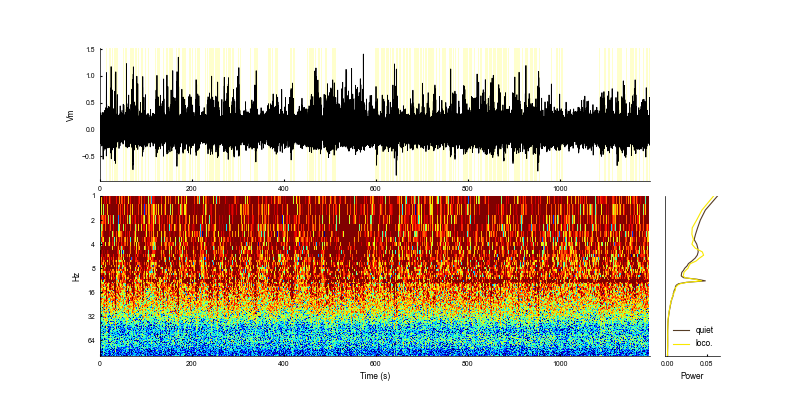

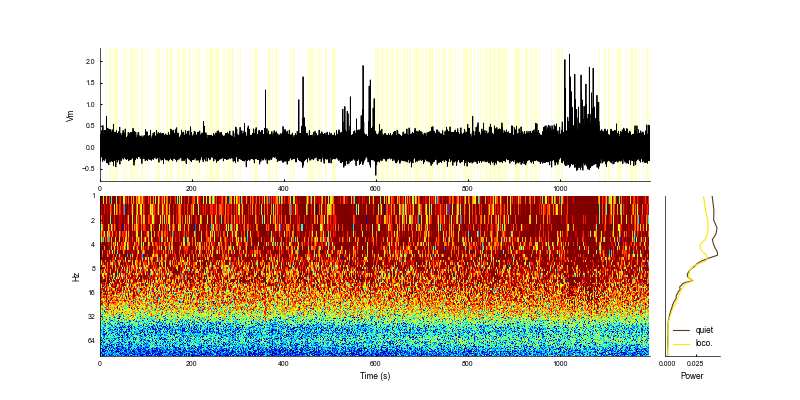

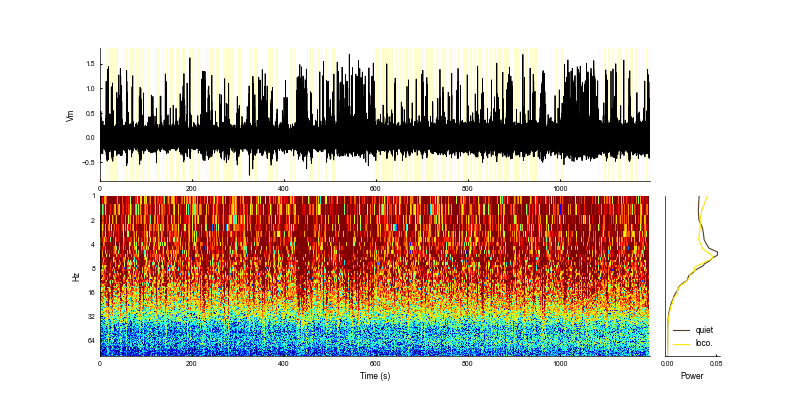

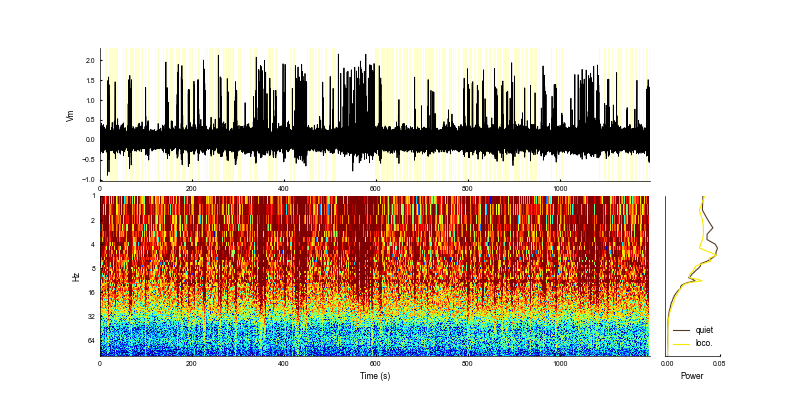

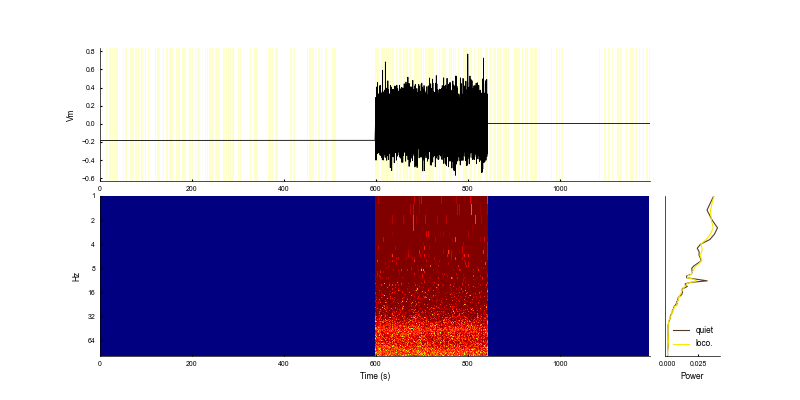

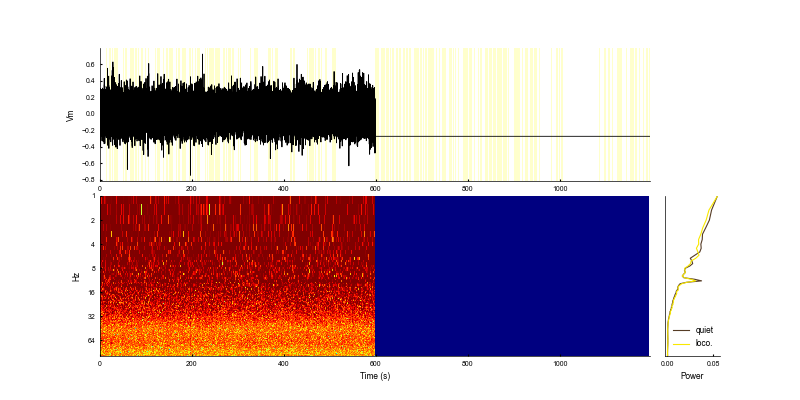

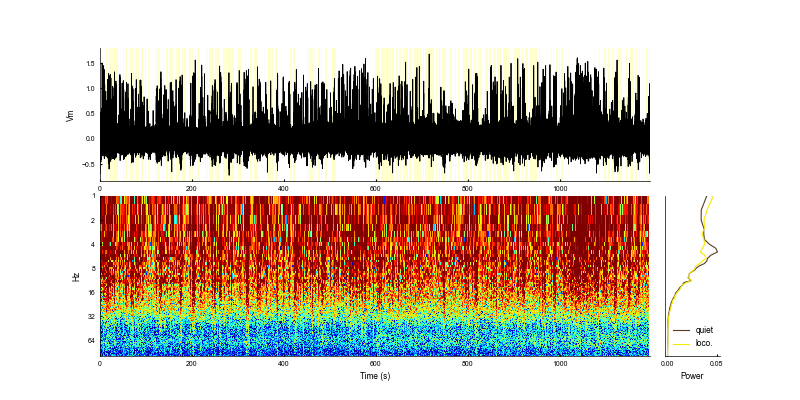

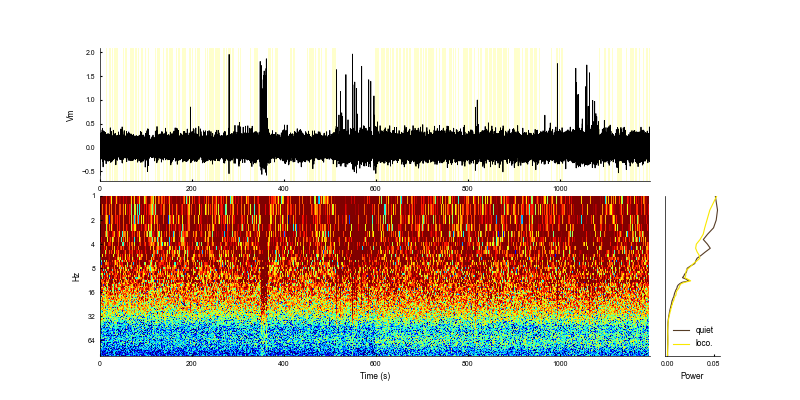

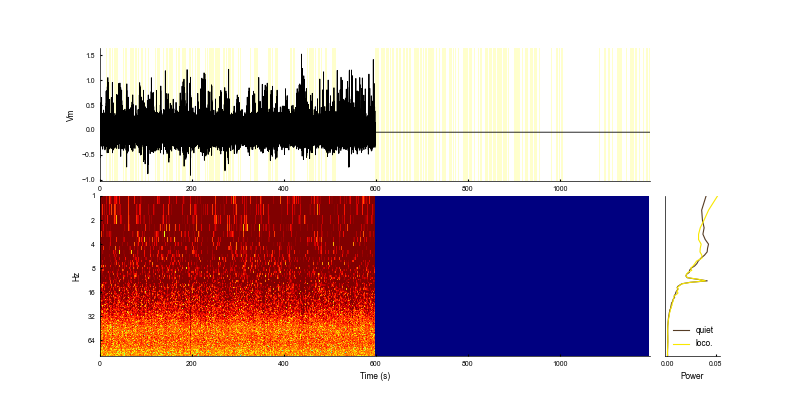

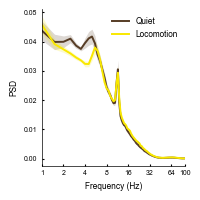

In [26]:
from utils.GRC_helpers import _compute_moving_epochs
import matplotlib.ticker as mticker

# moving/quiet epochs (same params as earlier cells)
trace = np.asarray(Vms[0], dtype=float)
speed_arr = np.asarray(speed, dtype=float)
speed_clean = speed_arr.copy()
speed_clean[speed_clean > 50] = np.nan
valid_frames = np.isfinite(speed_clean) & np.isfinite(trace)
speed_for_epochs = speed_clean.copy()
speed_for_epochs[~valid_frames] = np.nan

_, moving_epochs, moving_idx = _compute_moving_epochs(
    speed_for_epochs,
    frame_rate,
    kernel_size=kernel_size,
    filter_type="boxcar",
    speed_threshold=speed_threshold,
    min_duration_s=min_duration_s,
    merge_gap_s=merge_gap_s,
)

moving_mask = np.zeros(len(speed_arr), dtype=bool)
if len(moving_idx) > 0:
    moving_mask[moving_idx] = True
moving_mask &= valid_frames
quiet_mask = valid_frames & (~moving_mask)

psd_move_all = []
psd_quiet_all = []
freqs_ref = None

for cell_idx in range(len(Vms)):
    trace = np.asarray(Vms[cell_idx], dtype=float)
    t = np.arange(trace.size) / frame_rate
    # Skip cells with all NaN traces
    if np.all(np.isnan(trace)):
        print(f"Skipping cell {cell_idx}: all NaN")
        continue

    # spectrogram
    spec = compute_vm_spectrogram(Vms, cell_idx=cell_idx, frame_rate=frame_rate)
    power_db = 10 * np.log10(spec["power"] + 1e-12)
    vmin, vmax = np.percentile(power_db, [5, 95])
    # map spectrogram time bins to moving/quiet
    time_idx = np.round(spec["times"] * frame_rate).astype(int)
    time_idx = np.clip(time_idx, 0, len(moving_mask) - 1)
    moving_t = moving_mask[time_idx]
    quiet_t = quiet_mask[time_idx]

    mean_power_move = (
        np.nanmean(spec["power"][:, moving_t], axis=1) if np.any(moving_t)
        else np.full(spec["freqs"].shape, np.nan)
    )
    mean_power_quiet = (
        np.nanmean(spec["power"][:, quiet_t], axis=1) if np.any(quiet_t)
        else np.full(spec["freqs"].shape, np.nan)
    )

    if freqs_ref is None:
        freqs_ref = spec["freqs"]

    #normalize to total power
    mean_power_move /= np.nansum(mean_power_move)
    mean_power_quiet /= np.nansum(mean_power_quiet)

    # normalize to power in 1-20 Hz
    # freq_mask = (spec["freqs"] >= 20) & (spec["freqs"] <= 100)
    # total_power_move = np.nansum(mean_power_move[freq_mask])
    # total_power_quiet = np.nansum(mean_power_quiet[freq_mask])
    # if total_power_move > 0:
    #     mean_power_move /= total_power_move
    # if total_power_quiet > 0:
    #     mean_power_quiet /= total_power_quiet

    psd_move_all.append(mean_power_move)
    psd_quiet_all.append(mean_power_quiet)


    fig, axes = plt.subplots(
        2, 2, figsize=(8, 4),
        gridspec_kw={"width_ratios": [10, 1], "height_ratios": [1, 1.2],
                    "wspace": 0.05, "hspace": 0.1}
    )

    ax_vm = axes[0, 0]
    ax_empty = axes[0, 1]
    ax_sp = axes[1, 0]
    ax_psd = axes[1, 1]

    ax_sp.sharex(ax_vm)
    ax_psd.sharey(ax_sp)

    ax_vm.plot(t, trace, color="black", linewidth=0.6)
    ax_vm.set_ylabel("Vm")

    # shade moving epochs on Vm
    for start, end in moving_epochs:
        ax_vm.axvspan(start / frame_rate, end / frame_rate, color="yellow", alpha=0.2, lw=0)

    mesh = ax_sp.pcolormesh(
        spec["times"], spec["freqs"], power_db,
        shading="auto", cmap="jet", vmin=vmin, vmax=vmax
    )
    ax_sp.set_ylabel("Hz")
    ax_sp.set_xlabel("Time (s)")
    ax_sp.set_ylim(1, 100)
    ax_sp.set_xlim(t[0], t[-1])
    ax_sp.set_yscale("log", base=2)
    ax_sp.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))


    # PSDs: moving vs quiet (linear power)
    ax_psd.plot(mean_power_quiet, spec["freqs"], color=rest_color, linewidth=0.8, label="quiet")
    ax_psd.plot(mean_power_move, spec["freqs"], color=run_color, linewidth=0.8, label="loco.")
    
    ax_psd.set_xlabel("Power")
    ax_psd.tick_params(left=False, labelleft=False)
    ax_psd.legend(frameon=False, fontsize=6)

    ax_psd.invert_yaxis()  # flip left/right

    ax_psd.tick_params(left=False, labelleft=False)

    ax_empty.axis("off")

    for ax in [ax_vm, ax_sp, ax_psd]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()


max_freq = 100

if psd_move_all and psd_quiet_all:
    psd_move_all = np.vstack(psd_move_all)
    psd_quiet_all = np.vstack(psd_quiet_all)

    # Save pooled PSD arrays for cross-FOV pooling
    npz_out = os.path.join(data_folder, f'psd_spectrogram_state_speed{speed_threshold}.npz')
    np.savez(
        npz_out,
        freqs=freqs_ref,
        psd_move_cells=psd_move_all,
        psd_quiet_cells=psd_quiet_all,
    )
    print(f'Saved to {npz_out}')

    freqs_plot = freqs_ref
    freq_mask = (freqs_plot > 0) & (freqs_plot <= max_freq)
    freqs_plot = freqs_plot[freq_mask]

    psd_move_mean = np.nanmean(psd_move_all, axis=0)[freq_mask]
    psd_move_sem = np.nanstd(psd_move_all, axis=0) / np.sqrt(psd_move_all.shape[0])
    psd_move_sem = psd_move_sem[freq_mask]

    psd_quiet_mean = np.nanmean(psd_quiet_all, axis=0)[freq_mask]
    psd_quiet_sem = np.nanstd(psd_quiet_all, axis=0) / np.sqrt(psd_quiet_all.shape[0])
    psd_quiet_sem = psd_quiet_sem[freq_mask]

    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    ax.plot(freqs_plot, psd_quiet_mean, color=rest_color, linewidth=1.4, label='Quiet')

    ax.fill_between(
        freqs_plot,
        psd_quiet_mean - psd_quiet_sem,
        psd_quiet_mean + psd_quiet_sem,
        color=rest_color,
        alpha=0.2,
        linewidth=0,
    )

    ax.plot(freqs_plot, psd_move_mean, color=run_color, linewidth=1.4, label='Locomotion')
    
    ax.fill_between(
        freqs_plot,
        psd_move_mean - psd_move_sem,
        psd_move_mean + psd_move_sem,
        color=run_color,
        alpha=0.2,
        linewidth=0,
    )

    ax.set_xscale('log', base=2)
    ax.set_xlim(1, max_freq)
    ticks = [1, 2, 4, 8, 16, 32, 64, 100]
    ticks = [t for t in ticks if t <= max_freq]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.legend(frameon=False, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    # save figure
    out_path = os.path.join(figure_save_folder, 'PSD_state_avg_fixedChunks.svg')
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
else:
    print('No valid PSD data to plot.')


# Regress bandpassed Vm against SS and CS firing rates

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_by_burst_type_all_cells/PSD_state_burstType_cell0.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_by_burst_type_all_cells/PSD_state_burstType_cell1.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_by_burst_type_all_cells/PSD_state_burstType_cell2.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_by_burst_type_all_cells/PSD_state_burstType_cell3.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_by_burst_type_all_cells/PSD_state_burstType_cell4.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PSD_by_burst_type_all_cells/PSD_state_burstType_cell5.svg
Saved to /Users/qixiny

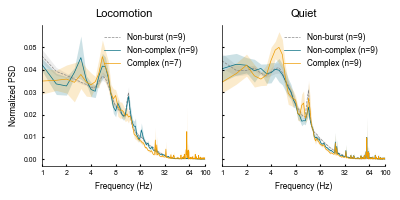

In [27]:
# PSD analysis: Complex vs Non-Complex Bursts, separated by behavioral state (Moving vs Quiet)
import matplotlib.ticker as mticker
from utils.GRC_helpers import _compute_moving_epochs

# Toggle to also plot non-burst PSD
plot_non_burst = True
non_burst_color = '#888888'  # gray for non-burst periods

# Normalize PSD by total power (True/False)
normalize_by_total_power = True

complex_color = '#EE9B00'  # red for complex bursts
simple_color = '#026C80'   # blue for non-complex bursts
figure_save_folder_burst_psd = os.path.join(figure_save_folder, 'PSD_by_burst_type_all_cells')
if not os.path.exists(figure_save_folder_burst_psd):
    os.makedirs(figure_save_folder_burst_psd)

# Minimum number of bursts required per condition
min_bursts_threshold = 5
linewidth = 0.5

# Compute moving/quiet epochs (same params as earlier cells)
trace_ref = np.asarray(Vms[0], dtype=float)
speed_arr = np.asarray(speed, dtype=float)
speed_clean = speed_arr.copy()
speed_clean[speed_clean > 50] = np.nan
valid_frames = np.isfinite(speed_clean) & np.isfinite(trace_ref)
speed_for_epochs = speed_clean.copy()
speed_for_epochs[~valid_frames] = np.nan

_, moving_epochs, moving_idx = _compute_moving_epochs(
    speed_for_epochs,
    frame_rate,
    kernel_size=kernel_size,
    filter_type="boxcar",
    speed_threshold=speed_threshold,
    min_duration_s=min_duration_s,
    merge_gap_s=merge_gap_s,
)

moving_mask = np.zeros(len(speed_arr), dtype=bool)
if len(moving_idx) > 0:
    moving_mask[moving_idx] = True
moving_mask &= valid_frames
quiet_mask = valid_frames & (~moving_mask)

# Storage for grand averages: dict with keys (state, burst_type)
# state: 'moving' or 'quiet', burst_type: 'complex', 'simple', or 'non_burst'
psd_grand = {
    ('moving', 'complex'): [],
    ('moving', 'simple'): [],
    ('quiet', 'complex'): [],
    ('quiet', 'simple'): [],
    ('moving', 'non_burst'): [],
    ('quiet', 'non_burst'): [],
}
freqs_ref = None

# Track cell indices for each PSD entry (for filtering in pooled analysis)
cell_indices = {
    'psd_moving_complex': [],
    'psd_moving_simple': [],
    'psd_quiet_complex': [],
    'psd_quiet_simple': [],
    'psd_moving_nonburst': [],
    'psd_quiet_nonburst': [],
}
max_freq = 100

for cell_idx in range(len(Vms)):
    trace = np.asarray(Vms[cell_idx], dtype=float)
    n_frames = len(trace)
    # Skip cells with all NaN traces
    if np.all(np.isnan(trace)):
        print(f"Skipping cell {cell_idx}: all NaN")
        continue
    # Get burst metrics for this cell
    cell_bursts = burst_metrics[cell_idx]
    
    # Categorize bursts by state and type
    # Count bursts in each condition and create masks
    burst_masks = {
        ('moving', 'complex'): np.zeros(n_frames, dtype=bool),
        ('moving', 'simple'): np.zeros(n_frames, dtype=bool),
        ('quiet', 'complex'): np.zeros(n_frames, dtype=bool),
        ('quiet', 'simple'): np.zeros(n_frames, dtype=bool),
    }
    burst_counts = {k: 0 for k in burst_masks.keys()}
    
    # Track all burst frames
    any_burst_mask = np.zeros(n_frames, dtype=bool)
    
    for burst in cell_bursts:
        start = int(burst['start'])
        end = int(burst['end'])
        start = max(0, start)
        end = min(n_frames, end)
        
        # Determine if burst is during moving or quiet
        burst_frames = np.arange(start, end)
        if len(burst_frames) == 0:
            continue
        moving_frac = np.mean(moving_mask[burst_frames])
        state = 'moving' if moving_frac >= 0.5 else 'quiet'
        burst_type = 'complex' if burst['is_complex'] else 'simple'
        
        burst_masks[(state, burst_type)][start:end] = True
        burst_counts[(state, burst_type)] += 1
        any_burst_mask[start:end] = True
    
    # Create non-burst masks for each state
    non_burst_masks = {
        ('moving', 'non_burst'): moving_mask & (~any_burst_mask),
        ('quiet', 'non_burst'): quiet_mask & (~any_burst_mask),
    }
    
    # Compute spectrogram
    spec = compute_vm_spectrogram(Vms, cell_idx=cell_idx, frame_rate=frame_rate)
    
    if freqs_ref is None:
        freqs_ref = spec["freqs"]
    
    # Map spectrogram time bins to frame indices
    time_idx = np.round(spec["times"] * frame_rate).astype(int)
    time_idx = np.clip(time_idx, 0, n_frames - 1)
    
    # Compute PSD for each burst condition
    psd_cell = {}
    for key in burst_masks.keys():
        mask_t = burst_masks[key][time_idx]
        n_bursts = burst_counts[key]
        
        if n_bursts >= min_bursts_threshold and np.any(mask_t):
            mean_power = np.nanmean(spec["power"][:, mask_t], axis=1)
            if normalize_by_total_power:
                total_power = np.nansum(mean_power)
                if total_power > 0:
                    mean_power = mean_power / total_power
            psd_cell[key] = mean_power
            psd_grand[key].append(mean_power)
            # Track cell index for this PSD entry
            npz_key = 'psd_' + key[0] + '_' + ('nonburst' if key[1] == 'non_burst' else key[1])
            cell_indices[npz_key].append(cell_idx)
        else:
            psd_cell[key] = None
    
    # Compute PSD for non-burst periods
    for key in non_burst_masks.keys():
        mask_t = non_burst_masks[key][time_idx]
        if np.any(mask_t):
            mean_power = np.nanmean(spec["power"][:, mask_t], axis=1)
            if normalize_by_total_power:
                total_power = np.nansum(mean_power)
                if total_power > 0:
                    mean_power = mean_power / total_power
            psd_cell[key] = mean_power
            psd_grand[key].append(mean_power)
            # Track cell index for this PSD entry
            npz_key = 'psd_' + key[0] + '_' + ('nonburst' if key[1] == 'non_burst' else key[1])
            cell_indices[npz_key].append(cell_idx)
        else:
            psd_cell[key] = None
    
    # Plot per-cell: 2 subplots side by side (Moving | Quiet)
    fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
    
    freqs_plot = spec["freqs"]
    freq_mask_plot = (freqs_plot > 0) & (freqs_plot <= max_freq)
    
    for ax, state, title in zip(axes, ['moving', 'quiet'], ['Locomotion', 'Quiet']):
        psd_simple = psd_cell[(state, 'simple')]
        psd_complex = psd_cell[(state, 'complex')]
        psd_nonburst = psd_cell.get((state, 'non_burst'), None)
        
        has_data = False
        
        # Plot non-burst first (background)
        if plot_non_burst and psd_nonburst is not None:
            ax.plot(freqs_plot[freq_mask_plot], psd_nonburst[freq_mask_plot], 
                    color=non_burst_color, linewidth=linewidth, linestyle='--', label='Non-burst')
            has_data = True
        
        if psd_simple is not None:
            ax.plot(freqs_plot[freq_mask_plot], psd_simple[freq_mask_plot], 
                    color=simple_color, linewidth=linewidth, label=f'Non-complex (n={burst_counts[(state, "simple")]})')
            has_data = True
        if psd_complex is not None:
            ax.plot(freqs_plot[freq_mask_plot], psd_complex[freq_mask_plot], 
                    color=complex_color, linewidth=linewidth, label=f'Complex (n={burst_counts[(state, "complex")]})')
            has_data = True
        
        ax.set_xscale('log', base=2)
        ax.set_xlim(1, max_freq)
        ticks = [1, 2, 4, 8, 16, 32, 64, 100]
        ticks = [t for t in ticks if t <= max_freq]
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        ax.set_xlabel('Frequency (Hz)')
        ax.set_title(title, fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if has_data:
            ax.legend(frameon=False, fontsize=5, loc='upper right')
        if not has_data:
            ax.text(0.5, 0.5, '<5 bursts', ha='center', va='center', 
                    transform=ax.transAxes, fontsize=8, color='gray')
    
    ylabel = 'Normalized PSD' if normalize_by_total_power else 'PSD'
    axes[0].set_ylabel(ylabel)
    fig.suptitle(f'Cell {cell_idx}', fontsize=10)
    plt.tight_layout()
    out_path = os.path.join(figure_save_folder_burst_psd, f'PSD_state_burstType_cell{cell_idx}.svg')
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
    plt.close(fig)

# Grand average across all cells
fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

freqs_plot_full = freqs_ref
freq_mask = (freqs_plot_full > 0) & (freqs_plot_full <= max_freq)
freqs_plot = freqs_plot_full[freq_mask]

for ax, state, title in zip(axes, ['moving', 'quiet'], ['Locomotion', 'Quiet']):
    # Plot non-burst first (background)
    if plot_non_burst:
        psd_list = psd_grand[(state, 'non_burst')]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask]
            psd_sem = np.nanstd(psd_arr, axis=0) / np.sqrt(psd_arr.shape[0])
            psd_sem = psd_sem[freq_mask]
            
            ax.plot(freqs_plot, psd_mean, color=non_burst_color, linewidth=linewidth, 
                    linestyle='--', label=f'Non-burst (n={len(psd_list)})')
            ax.fill_between(
                freqs_plot,
                psd_mean - psd_sem,
                psd_mean + psd_sem,
                color=non_burst_color,
                alpha=0.15,
                linewidth=0,
            )
    
    for burst_type, color, label in [('simple', simple_color, 'Non-complex'), 
                                      ('complex', complex_color, 'Complex')]:
        psd_list = psd_grand[(state, burst_type)]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask]
            psd_sem = np.nanstd(psd_arr, axis=0) / np.sqrt(psd_arr.shape[0])
            psd_sem = psd_sem[freq_mask]
            
            ax.plot(freqs_plot, psd_mean, color=color, linewidth=linewidth, 
                    label=f'{label} (n={len(psd_list)})')
            ax.fill_between(
                freqs_plot,
                psd_mean - psd_sem,
                psd_mean + psd_sem,
                color=color,
                alpha=0.2,
                linewidth=0,
            )
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(1, max_freq)
    ticks = [1, 2, 4, 8, 16, 32, 64, 100]
    ticks = [t for t in ticks if t <= max_freq]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=6, loc='upper right')

ylabel = 'Normalized PSD' if normalize_by_total_power else 'PSD'
axes[0].set_ylabel(ylabel)
#fig.suptitle('Grand Average: PSD by State & Burst Type', fontsize=11)
plt.tight_layout()

# Save PSD data for cross-FOV pooling
npz_out = os.path.join(data_folder, f'psd_burstType_state_speed{speed_threshold}.npz')
np.savez(
    npz_out,
    freqs=freqs_ref,
    normalize_by_total_power=normalize_by_total_power,
    psd_moving_complex=np.vstack(psd_grand[('moving', 'complex')]) if psd_grand[('moving', 'complex')] else np.array([]),
    psd_moving_simple=np.vstack(psd_grand[('moving', 'simple')]) if psd_grand[('moving', 'simple')] else np.array([]),
    psd_quiet_complex=np.vstack(psd_grand[('quiet', 'complex')]) if psd_grand[('quiet', 'complex')] else np.array([]),
    psd_quiet_simple=np.vstack(psd_grand[('quiet', 'simple')]) if psd_grand[('quiet', 'simple')] else np.array([]),
    psd_moving_nonburst=np.vstack(psd_grand[('moving', 'non_burst')]) if psd_grand[('moving', 'non_burst')] else np.array([]),
    psd_quiet_nonburst=np.vstack(psd_grand[('quiet', 'non_burst')]) if psd_grand[('quiet', 'non_burst')] else np.array([]),
    cell_indices=cell_indices,
)
print(f'Saved PSD data to {npz_out}')

# Save figure
out_path = os.path.join(figure_save_folder, 'PSD_state_burstType_avg.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Trial by Trial theta and slow Vm plotting during PF traversal

In [13]:
# theta_freqs = (4, 8)
# slow_freqs = 2
# min_duration_ms = 500
# min_distance_cm = 5
# clear_traversal = True
# session_indices = [0,1]
# show_rest_patches = False
# pf_center_window_sec = 4
# show_plots = False
# min_traversals = 10


# pf_centered_list = []
# time_rel = np.arange(
#     -int(round(pf_center_window_sec * frame_rate)),
#     int(round(pf_center_window_sec * frame_rate)) + 1,
# ) / frame_rate

# for cell_idx, analysis in enumerate(PC_output_all):
#     if not analysis.get('is_place_cell', False):
#         continue


#     ### Old version when traces are not normalized by spike heights
#     # sub_out = get_subthreshold_activity(
#     #     traces, all_spikes, all_CS_spikes, refined_SS, complex_bursts_dicts,
#     #     spike_heights_interpolated, ts_neural, frame_rate,
#     #     idx=cell_idx, mask_duration=1000,
#     #     theta_freqs=theta_freqs, slow_freqs=slow_freqs
#     # )
#     # trace = sub_out['trace']
#     # theta_vm = sub_out['theta_Vm']
#     # slow_vm = sub_out['slow_Vm']
#     #slow_vm = slow_vm - np.nanmedian(slow_vm)

#     trace = traces[cell_idx]
#     trace = interpolate_nan_segment(trace)
#     theta_vm = bandpass_filter(trace, theta_freqs[0], theta_freqs[1], frame_rate, order=5)
#     slow_vm = lowpass_filter(trace, slow_freqs, frame_rate, order=5)

#     traversal_epochs, place_field_mask, rate_map, pf_bins, traversal_types = find_place_field_traversals(
#         x_neural, y_neural, spikes, speed, frame_rate, cell_idx,
#         analysis=analysis,
#         speed_threshold=speed_threshold,
#         min_duration_ms=min_duration_ms,
#         place_field_threshold=place_field_threshold,
#         min_distance_cm=min_distance_cm,
#         clear_traversal=clear_traversal,
#         return_traversal_types=True,
#     )
#     if len(traversal_epochs) < min_traversals:
#         continue

#     pf_peak_xy = None
#     if place_field_mask is not None and np.any(place_field_mask):
#         masked_rate = np.where(place_field_mask, rate_map, np.nan)
#         if np.any(np.isfinite(masked_rate)):
#             x_centers = (pf_bins[0][:-1] + pf_bins[0][1:]) / 2
#             y_centers = (pf_bins[1][:-1] + pf_bins[1][1:]) / 2
#             peak_idx = np.nanargmax(masked_rate)
#             peak_row, peak_col = np.unravel_index(peak_idx, masked_rate.shape)
#             pf_peak_xy = (x_centers[peak_row], y_centers[peak_col])

#     fig, axes, valid_epochs, theta_mean, slow_mean, rate_mean, ss_rate_mean, cs_rate_mean, ss_pct_mean, cs_pct_mean = plot_place_field_traversal_trials_with_cb_example(
#         trace, theta_vm, slow_vm, speed, x_neural, y_neural,
#         traversal_epochs, place_field_mask, pf_bins, frame_rate,
#         complex_bursts_dicts=complex_bursts_dicts,
#         cell_idx=cell_idx,
#         traversal_types=traversal_types,
#         padding_sec=pf_center_window_sec,
#         zscore_traces=False,
#         theta_freqs=theta_freqs,
#         slow_freqs=slow_freqs,
#         session_start_frames=session_start_frames,
#         session_indices=session_indices,
#         color_by_session=True,
#         show_rest_patches=show_rest_patches,
#         refined_SS=refined_SS,
#         all_CS_spikes=all_CS_spikes,
#         all_spikes=all_spikes,
#         firing_rate_bin_ms=100,
#         firing_rate_smooth_ms=50,
#         show_firing_rate=False,
#         simple_spike_color='#026C80',
#         complex_spike_color='#EE9B00',
#         pf_peak_xy=pf_peak_xy,
#         pf_center_window_sec=pf_center_window_sec,
#         plot_pf_centered_average=True,
#         return_pf_centered=True,
#         return_spike_rate_means=True,
#         show=show_plots,
#         bad_timepoints=bad_masks[cell_idx] if bad_masks is not None else None,
#     )
    
#     if theta_mean is not None and slow_mean is not None and len(valid_epochs) > min_traversals:
#         pf_centered_list.append({
#             'cell_idx': cell_idx,
#             'theta_mean': theta_mean,
#             'slow_mean': slow_mean,
#             'rate_mean': rate_mean,
#             'ss_rate_mean': ss_rate_mean,
#             'cs_rate_mean': cs_rate_mean,
#             'ss_pct_mean': ss_pct_mean,
#             'cs_pct_mean': cs_pct_mean,
#         })
#     if fig is not None:
#         figure_save_folder_trial_by_trial = os.path.join(figure_save_folder, 'PF_traversal_trials_all_cells')
#         os.makedirs(figure_save_folder_trial_by_trial, exist_ok=True)
#         out_path = os.path.join(figure_save_folder_trial_by_trial, f'Cell{cell_idx+1}_PF_traversal.svg')
#         plt.rcParams['svg.fonttype'] = 'none'
#         plt.close(fig)
#         fig.savefig(out_path, dpi=300)
#         print(f'Saved to {out_path}')
#     if fig is not None and not show_plots:
#         plt.close(fig)



# save_path = os.path.join(data_folder, f'pf_centered_theta_slow.pkl')
# with open(save_path, 'wb') as f:
#     pickle.dump({
#         'time_rel': time_rel,
#         'pf_centered': pf_centered_list,
#         'theta_freqs': theta_freqs,
#         'slow_freqs': slow_freqs,
#     }, f)

# print(f'Saved PF-centered averages to {save_path}')



In [14]:
# example_idx = 2  # 0-based index (default: 3rd entry)
# plot_example = True
# smooth_example = True
# smooth_window = 250

# from matplotlib.ticker import FuncFormatter

# def _fmt_two_decimals(x, _):
#     return f"{x:.2f}".rstrip("0").rstrip(".")

# def _smooth_boxcar(trace, win=5):
#     arr = np.asarray(trace, dtype=float)
#     if win <= 1:
#         return arr
#     kernel = np.ones(win, dtype=float)
#     valid = np.isfinite(arr).astype(float)
#     arr_filled = np.where(np.isfinite(arr), arr, 0.0)
#     smoothed = np.convolve(arr_filled, kernel, mode="same")
#     counts = np.convolve(valid, kernel, mode="same")
#     with np.errstate(invalid="ignore", divide="ignore"):
#         smoothed = np.where(counts > 0, smoothed / counts, np.nan)
#     return smoothed

# if plot_example and len(pf_centered_list) > 0:
#     idx = min(example_idx, len(pf_centered_list) - 1)
#     entry = pf_centered_list[idx]
#     theta = entry.get('theta_mean')
#     slow = entry.get('slow_mean')
#     rate = entry.get('rate_mean')
#     ss_rate = entry.get('ss_rate_mean')
#     cs_rate = entry.get('cs_rate_mean')
#     ss_pct = entry.get('ss_pct_mean')
#     cs_pct = entry.get('cs_pct_mean')

#     if rate is not None and len(rate) == len(time_rel):
#         rate = np.asarray(rate, dtype=float)
#     else:
#         rate = None

#     if ss_rate is not None and len(ss_rate) == len(time_rel):
#         ss_rate = np.asarray(ss_rate, dtype=float)
#     else:
#         ss_rate = None

#     if cs_rate is not None and len(cs_rate) == len(time_rel):
#         cs_rate = np.asarray(cs_rate, dtype=float)
#     else:
#         cs_rate = None

#     if ss_pct is not None and len(ss_pct) == len(time_rel):
#         ss_pct = np.asarray(ss_pct, dtype=float)
#     else:
#         ss_pct = None

#     if cs_pct is not None and len(cs_pct) == len(time_rel):
#         cs_pct = np.asarray(cs_pct, dtype=float)
#     else:
#         cs_pct = None

#     if ss_pct is None or cs_pct is None:
#         if ss_rate is not None and cs_rate is not None:
#             denom = ss_rate + cs_rate
#             valid = np.isfinite(denom) & (denom > 0)
#             ss_pct = np.where(valid, 100.0 * ss_rate / denom, np.nan)
#             cs_pct = np.where(valid, 100.0 * cs_rate / denom, np.nan)
#         else:
#             ss_pct = None
#             cs_pct = None

#     if smooth_example:
#         if theta is not None and len(theta) == len(time_rel):
#             theta = _smooth_boxcar(theta, smooth_window)
#         if slow is not None and len(slow) == len(time_rel):
#             slow = _smooth_boxcar(slow, smooth_window)
#         if rate is not None and len(rate) == len(time_rel):
#             rate = _smooth_boxcar(rate, smooth_window)
#         if ss_rate is not None and len(ss_rate) == len(time_rel):
#             ss_rate = _smooth_boxcar(ss_rate, smooth_window)
#         if cs_rate is not None and len(cs_rate) == len(time_rel):
#             cs_rate = _smooth_boxcar(cs_rate, smooth_window)
#         if ss_pct is not None and len(ss_pct) == len(time_rel):
#             ss_pct = _smooth_boxcar(ss_pct, smooth_window)
#         if cs_pct is not None and len(cs_pct) == len(time_rel):
#             cs_pct = _smooth_boxcar(cs_pct, smooth_window)

#     fig, axes = plt.subplots(5, 1, figsize=(2, 3.6), sharex=True)

#     if rate is not None and len(rate) == len(time_rel):
#         axes[0].plot(time_rel, rate, color='#555555', linewidth=1.0)
#         axes[0].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[0].set_ylabel('FR (Hz)', fontsize=6, fontname='Arial')
#     else:
#         axes[0].text(
#             0.5, 0.5, 'No FR data', transform=axes[0].transAxes,
#             ha='center', va='center', fontsize=6, fontname='Arial'
#         )
#         axes[0].set_ylabel('FR (Hz)', fontsize=6, fontname='Arial')

#     if (ss_rate is not None and len(ss_rate) == len(time_rel)) or (cs_rate is not None and len(cs_rate) == len(time_rel)):
#         if ss_rate is not None:
#             axes[1].plot(time_rel, ss_rate, color='#026C80', linewidth=1.0)
#         if cs_rate is not None:
#             axes[1].plot(time_rel, cs_rate, color='#EE9B00', linewidth=1.0)
#         axes[1].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[1].set_ylabel('SS/CS FR\n(Hz)', fontsize=6, fontname='Arial')
#     else:
#         axes[1].text(
#             0.5, 0.5, 'No SS/CS FR data', transform=axes[1].transAxes,
#             ha='center', va='center', fontsize=6, fontname='Arial'
#         )
#         axes[1].set_ylabel('SS/CS FR\n(Hz)', fontsize=6, fontname='Arial')

#     if (ss_pct is not None and len(ss_pct) == len(time_rel)) or (cs_pct is not None and len(cs_pct) == len(time_rel)):
#         if ss_pct is not None:
#             axes[2].plot(time_rel, ss_pct, color='#026C80', linewidth=1.0)
#         if cs_pct is not None:
#             axes[2].plot(time_rel, cs_pct, color='#EE9B00', linewidth=1.0)
#         axes[2].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')
#     else:
#         axes[2].text(
#             0.5, 0.5, 'No SS/CS % data', transform=axes[2].transAxes,
#             ha='center', va='center', fontsize=6, fontname='Arial'
#         )
#         axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')

#     if theta is not None and len(theta) == len(time_rel):
#         axes[3].plot(time_rel, theta, color='blue', linewidth=1.0)
#         axes[3].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[3].set_ylabel('$\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')
#     else:
#         axes[3].text(
#             0.5, 0.5, 'No theta data', transform=axes[3].transAxes,
#             ha='center', va='center', fontsize=6, fontname='Arial'
#         )
#         axes[3].set_ylabel('$\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')

#     if slow is not None and len(slow) == len(time_rel):
#         axes[4].plot(time_rel, slow, color='red', linewidth=1.0)
#         axes[4].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')
#     else:
#         axes[4].text(
#             0.5, 0.5, 'No slow data', transform=axes[4].transAxes,
#             ha='center', va='center', fontsize=6, fontname='Arial'
#         )
#         axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')

#     axes[4].set_xlabel('Time from PF peak (s)', fontsize=6, fontname='Arial')
#     for ax in axes:
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)
#         ax.tick_params(labelsize=5)
#         ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
#         for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
#             label.set_fontname('Arial')

#     axes[2].set_ylim(0, 100)
#     axes[3].set_ylim(-0.03, 0.07)
#     axes[4].set_ylim(-0.025, 0.06)

#     plt.tight_layout(rect=[0, 0, 1, 0.95])

#     example_out_path = os.path.join(
#         figure_save_folder,
#         f'pf_centered_example_cell{idx + 1}.svg',
#     )
#     fig.savefig(example_out_path, dpi=300)
#     print(f"Saved example plot to {example_out_path}")
#     print(f"Plotted example cell index {idx} (cell_idx={entry.get('cell_idx')})")

#     plt.show()
# else:
#     print('No PF-centered averages available for example plot.')


In [15]:
# if len(pf_centered_list) > 0:
#     theta_stack = [
#         entry['theta_mean']
#         for entry in pf_centered_list
#         if entry.get('theta_mean') is not None and len(entry['theta_mean']) == len(time_rel)
#     ]
#     slow_stack = [
#         entry['slow_mean']
#         for entry in pf_centered_list
#         if entry.get('slow_mean') is not None and len(entry['slow_mean']) == len(time_rel)
#     ]
#     rate_stack = []
#     ss_cs_pairs = []
#     zero_idx = len(time_rel) // 2
#     for entry in pf_centered_list:
#         rate = entry.get('rate_mean')
#         if rate is not None and len(rate) == len(time_rel):
#             rate = np.asarray(rate, dtype=float)
#             rate_stack.append(rate)
#         else:
#             rate = None
#         ss_rate = entry.get('ss_rate_mean')
#         cs_rate = entry.get('cs_rate_mean')
#         if ss_rate is None or cs_rate is None or rate is None:
#             continue
#         if len(ss_rate) != len(time_rel) or len(cs_rate) != len(time_rel):
#             continue
#         ss_rate = np.asarray(ss_rate, dtype=float)
#         cs_rate = np.asarray(cs_rate, dtype=float)
#         if not np.any(np.isfinite(cs_rate)) or np.nanmax(cs_rate) <= 0:
#             continue
#         ss_cs_pairs.append((ss_rate, cs_rate, rate))

#     plot_individual = True
#     smooth_individual = True

#     def _smooth_boxcar(trace, win=5):
#         arr = np.asarray(trace, dtype=float)
#         if win <= 1:
#             return arr
#         kernel = np.ones(win, dtype=float)
#         valid = np.isfinite(arr).astype(float)
#         arr_filled = np.where(np.isfinite(arr), arr, 0.0)
#         smoothed = np.convolve(arr_filled, kernel, mode="same")
#         counts = np.convolve(valid, kernel, mode="same")
#         with np.errstate(invalid="ignore", divide="ignore"):
#             smoothed = np.where(counts > 0, smoothed / counts, np.nan)
#         return smoothed

#     def _prep_stack(stack):
#         if not smooth_individual:
#             return stack
#         return [_smooth_boxcar(trace, smooth_window) for trace in stack]

#     def _prep_pair_stack(pair_stack):
#         if not smooth_individual:
#             return pair_stack
#         smoothed = []
#         for ss_rate, cs_rate, total_rate in pair_stack:
#             smoothed.append((
#                 _smooth_boxcar(ss_rate, smooth_window),
#                 _smooth_boxcar(cs_rate, smooth_window),
#                 _smooth_boxcar(total_rate, smooth_window),
#             ))
#         return smoothed

#     def _normalize_rate(trace):
#         if trace is None or len(trace) != len(time_rel):
#             return None
#         trace = np.asarray(trace, dtype=float)
#         if not np.any(np.isfinite(trace)):
#             return None
#         norm_val = trace[zero_idx]
#         if not np.isfinite(norm_val) or norm_val == 0:
#             peak = np.nanmax(trace)
#             if not np.isfinite(peak) or peak == 0:
#                 return None
#             norm_val = peak
#         return trace / norm_val

#     theta_stack_use = _prep_stack(theta_stack)
#     slow_stack_use = _prep_stack(slow_stack)
#     rate_stack_use = [_normalize_rate(rate) for rate in _prep_stack(rate_stack)]
#     rate_stack_use = [rate for rate in rate_stack_use if rate is not None]

#     ss_norm_stack_use = []
#     cs_norm_stack_use = []
#     ss_percent_stack = []
#     cs_percent_stack = []
#     for ss_rate, cs_rate, total_rate in _prep_pair_stack(ss_cs_pairs):
#         denom_total = total_rate[zero_idx]
#         if np.isfinite(denom_total) and denom_total > 0:
#             ss_norm = ss_rate / denom_total
#             cs_norm = cs_rate / denom_total
#             if np.any(np.isfinite(ss_norm)):
#                 ss_norm_stack_use.append(ss_norm)
#                 cs_norm_stack_use.append(cs_norm)
#         denom = ss_rate + cs_rate
#         valid = np.isfinite(denom) & (denom > 0)
#         ss_pct = np.where(valid, 100.0 * ss_rate / denom, np.nan)
#         cs_pct = np.where(valid, 100.0 * cs_rate / denom, np.nan)
#         if np.any(np.isfinite(ss_pct)):
#             ss_percent_stack.append(ss_pct)
#             cs_percent_stack.append(cs_pct)

#     def mean_sem(stack):
#         if not stack:
#             return None, None
#         arr = np.vstack(stack)
#         mean = np.nanmean(arr, axis=0)
#         count = np.sum(np.isfinite(arr), axis=0)
#         std = np.nanstd(arr, axis=0, ddof=0)
#         sem = np.where(count > 0, std / np.sqrt(count), np.nan)
#         return mean, sem

#     from matplotlib.ticker import FuncFormatter

#     def _fmt_two_decimals(x, _):
#         return f"{x:.2f}".rstrip("0").rstrip(".")

#     theta_grand, theta_sem = mean_sem(theta_stack_use)
#     slow_grand, slow_sem = mean_sem(slow_stack_use)
#     rate_grand, rate_sem = mean_sem(rate_stack_use)
#     ss_norm_grand, ss_norm_sem = mean_sem(ss_norm_stack_use)
#     cs_norm_grand, cs_norm_sem = mean_sem(cs_norm_stack_use)
#     ss_pct_grand, ss_pct_sem = mean_sem(ss_percent_stack)
#     cs_pct_grand, cs_pct_sem = mean_sem(cs_percent_stack)

#     fig, axes = plt.subplots(5, 1, figsize=(2, 3.6), sharex=True)
#     if rate_grand is not None:
#         if plot_individual:
#             for rate in rate_stack_use:
#                 axes[0].plot(time_rel, rate, color='#555555', linewidth=0.5, alpha=0.2)
#         axes[0].plot(time_rel, rate_grand, color='#555555', linewidth=1.0)
#         if rate_sem is not None:
#             axes[0].fill_between(
#                 time_rel,
#                 rate_grand - rate_sem,
#                 rate_grand + rate_sem,
#                 color='#555555',
#                 alpha=0.2,
#                 linewidth=0,
#             )
#         axes[0].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[0].set_ylabel('Normalized FR', fontsize=6, fontname='Arial')
#     else:
#         axes[0].text(0.5, 0.5, 'No FR data', transform=axes[0].transAxes,
#                     ha='center', va='center', fontsize=6, fontname='Arial')
#         axes[0].set_ylabel('Normalized FR', fontsize=6, fontname='Arial')

#     if ss_norm_grand is not None or cs_norm_grand is not None:
#         if plot_individual:
#             for ss_norm in ss_norm_stack_use:
#                 axes[1].plot(time_rel, ss_norm, color='#026C80', linewidth=0.5, alpha=0.2)
#             for cs_norm in cs_norm_stack_use:
#                 axes[1].plot(time_rel, cs_norm, color='#EE9B00', linewidth=0.5, alpha=0.2)
#         if ss_norm_grand is not None:
#             axes[1].plot(time_rel, ss_norm_grand, color='#026C80', linewidth=1.0)
#             if ss_norm_sem is not None:
#                 axes[1].fill_between(
#                     time_rel,
#                     ss_norm_grand - ss_norm_sem,
#                     ss_norm_grand + ss_norm_sem,
#                     color='#026C80',
#                     alpha=0.2,
#                     linewidth=0,
#                 )
#         if cs_norm_grand is not None:
#             axes[1].plot(time_rel, cs_norm_grand, color='#EE9B00', linewidth=1.0)
#             if cs_norm_sem is not None:
#                 axes[1].fill_between(
#                     time_rel,
#                     cs_norm_grand - cs_norm_sem,
#                     cs_norm_grand + cs_norm_sem,
#                     color='#EE9B00',
#                     alpha=0.2,
#                     linewidth=0,
#                 )
#         axes[1].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[1].set_ylabel('% in SS/CS', fontsize=6, fontname='Arial')
#     else:
#         axes[1].text(0.5, 0.5, 'No SS/CS FR data', transform=axes[1].transAxes,
#                     ha='center', va='center', fontsize=6, fontname='Arial')
#         axes[1].set_ylabel('% in SS/CS', fontsize=6, fontname='Arial')
#     if ss_pct_grand is not None or cs_pct_grand is not None:
#         if plot_individual:
#             for trace in ss_percent_stack:
#                 axes[2].plot(time_rel, trace, color='#026C80', linewidth=0.5, alpha=0.2)
#             for trace in cs_percent_stack:
#                 axes[2].plot(time_rel, trace, color='#EE9B00', linewidth=0.5, alpha=0.2)
#         if ss_pct_grand is not None:
#             axes[2].plot(time_rel, ss_pct_grand, color='#026C80', linewidth=1.0)
#             if ss_pct_sem is not None:
#                 axes[2].fill_between(
#                     time_rel,
#                     ss_pct_grand - ss_pct_sem,
#                     ss_pct_grand + ss_pct_sem,
#                     color='#026C80',
#                     alpha=0.2,
#                     linewidth=0,
#                 )
#         if cs_pct_grand is not None:
#             axes[2].plot(time_rel, cs_pct_grand, color='#EE9B00', linewidth=1.0)
#             if cs_pct_sem is not None:
#                 axes[2].fill_between(
#                     time_rel,
#                     cs_pct_grand - cs_pct_sem,
#                     cs_pct_grand + cs_pct_sem,
#                     color='#EE9B00',
#                     alpha=0.2,
#                     linewidth=0,
#                 )
#         axes[2].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')
#     else:
#         axes[2].text(0.5, 0.5, 'No SS/CS % data', transform=axes[2].transAxes,
#                     ha='center', va='center', fontsize=6, fontname='Arial')
#         axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')

#     if theta_grand is not None:
#         if plot_individual:
#             for theta in theta_stack_use:
#                 axes[3].plot(time_rel, theta, color='blue', linewidth=0.5, alpha=0.2)
#         axes[3].plot(time_rel, theta_grand, color='blue', linewidth=1.0)
#         if theta_sem is not None:
#             axes[3].fill_between(
#                 time_rel,
#                 theta_grand - theta_sem,
#                 theta_grand + theta_sem,
#                 color='blue',
#                 alpha=0.2,
#                 linewidth=0,
#             )
#         axes[3].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[3].set_ylabel('$\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')
#     else:
#         axes[3].text(0.5, 0.5, 'No theta data', transform=axes[3].transAxes,
#                     ha='center', va='center', fontsize=6, fontname='Arial')
#         axes[3].set_ylabel('$\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')

#     if slow_grand is not None:
#         if plot_individual:
#             for slow in slow_stack_use:
#                 axes[4].plot(time_rel, slow, color='red', linewidth=0.5, alpha=0.2)
#         axes[4].plot(time_rel, slow_grand, color='red', linewidth=1.0)
#         if slow_sem is not None:
#             axes[4].fill_between(
#                 time_rel,
#                 slow_grand - slow_sem,
#                 slow_grand + slow_sem,
#                 color='red',
#                 alpha=0.2,
#                 linewidth=0,
#             )
#         axes[4].axvline(0, color='black', linewidth=0.6, alpha=0.6)
#         axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')
#     else:
#         axes[4].text(0.5, 0.5, 'No slow data', transform=axes[4].transAxes,
#                     ha='center', va='center', fontsize=6, fontname='Arial')
#         axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')

#     axes[4].set_xlabel('Time from PF peak (s)', fontsize=6, fontname='Arial')
#     for ax in axes:
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)
#         ax.tick_params(labelsize=5)
#         ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
#         for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
#             label.set_fontname('Arial')
#     # fig.suptitle(
#     #     f'Grand average (n={len(pf_centered_list)})',
#     #     fontsize=6,
#     #     fontname='Arial',
#     #     x=0.5,
#     # )
#     axes[0].set_ylim(0, 1.2)
#     axes[2].set_ylim(0, 100)
#     axes[3].set_ylim(-0.02, 0.1)
#     axes[4].set_ylim(-0.025, 0.06)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     grand_out_path = os.path.join(
#         figure_save_folder,
#         f'pf_centered_grand_avg.svg',
#     )
#     plt.rcParams['svg.fonttype'] = 'none'
#     fig.savefig(grand_out_path, dpi=300)
#     print(f'Saved grand average to {grand_out_path}')
#     print(
#         'N cells included:',
#         f'theta={len(theta_stack_use)}',
#         f'slow={len(slow_stack_use)}',
#         f'FR={len(rate_stack_use)}',
#         f'SS/CS FR={len(ss_norm_stack_use)}',
#         f'SS/CS %={len(ss_percent_stack)}',
#     )
#     plt.show()
# else:
#     print('No PF-centered averages available for grand plot.')


# Trial by Trial V2

In [9]:
theta_freqs = (4, 8)
slow_freqs = 2
min_duration_ms = 500
min_distance_cm = 5
clear_traversal = True
session_indices = [0,1]
show_rest_patches = False
pf_center_window_sec = 4
show_plots = False
min_traversals = 10


pf_centered_list = []
time_rel = np.arange(
    -int(round(pf_center_window_sec * frame_rate)),
    int(round(pf_center_window_sec * frame_rate)) + 1,
) / frame_rate

for cell_idx, analysis in enumerate(PC_output_all):
    if not analysis.get('is_place_cell', False):
        continue


    ### Old version when traces are not normalized by spike heights
    # sub_out = get_subthreshold_activity(
    #     traces, all_spikes, all_CS_spikes, refined_SS, complex_bursts_dicts,
    #     spike_heights_interpolated, ts_neural, frame_rate,
    #     idx=cell_idx, mask_duration=1000,
    #     theta_freqs=theta_freqs, slow_freqs=slow_freqs
    # )
    # trace = sub_out['trace']
    # theta_vm = sub_out['theta_Vm']
    # slow_vm = sub_out['slow_Vm']
    #slow_vm = slow_vm - np.nanmedian(slow_vm)

    trace = traces[cell_idx]
    trace = interpolate_nan_segment(trace)
    theta_vm = bandpass_filter(trace, theta_freqs[0], theta_freqs[1], frame_rate, order=5)
    slow_vm = lowpass_filter(trace, slow_freqs, frame_rate, order=5)

    traversal_epochs, place_field_mask, rate_map, pf_bins, traversal_types = find_place_field_traversals(
        x_neural, y_neural, spikes, speed, frame_rate, cell_idx,
        analysis=analysis,
        speed_threshold=speed_threshold,
        min_duration_ms=min_duration_ms,
        place_field_threshold=place_field_threshold,
        min_distance_cm=min_distance_cm,
        clear_traversal=clear_traversal,
        return_traversal_types=True,
    )
    if len(traversal_epochs) < min_traversals:
        continue

    pf_peak_xy = None
    if place_field_mask is not None and np.any(place_field_mask):
        masked_rate = np.where(place_field_mask, rate_map, np.nan)
        if np.any(np.isfinite(masked_rate)):
            x_centers = (pf_bins[0][:-1] + pf_bins[0][1:]) / 2
            y_centers = (pf_bins[1][:-1] + pf_bins[1][1:]) / 2
            peak_idx = np.nanargmax(masked_rate)
            peak_row, peak_col = np.unravel_index(peak_idx, masked_rate.shape)
            pf_peak_xy = (x_centers[peak_row], y_centers[peak_col])

    fig, axes, valid_epochs, theta_mean, slow_mean, rate_mean, ss_rate_mean, cs_rate_mean, ss_pct_mean, cs_pct_mean = plot_place_field_traversal_trials_with_cb_example_centered_by_max_rate(
        trace, theta_vm, slow_vm, speed, x_neural, y_neural,
        traversal_epochs, place_field_mask, pf_bins, frame_rate,
        complex_bursts_dicts=complex_bursts_dicts,
        cell_idx=cell_idx,
        traversal_types=traversal_types,
        padding_sec=pf_center_window_sec,
        zscore_traces=False,
        theta_freqs=theta_freqs,
        slow_freqs=slow_freqs,
        session_start_frames=session_start_frames,
        session_indices=session_indices,
        color_by_session=True,
        show_rest_patches=show_rest_patches,
        refined_SS=refined_SS,
        all_CS_spikes=all_CS_spikes,
        all_spikes=all_spikes,
        firing_rate_bin_ms=100,
        firing_rate_smooth_ms=50,
        show_firing_rate=False,
        simple_spike_color='#026C80',
        complex_spike_color='#EE9B00',
        pf_peak_xy=pf_peak_xy,
        pf_center_window_sec=pf_center_window_sec,
        plot_pf_centered_average=True,
        return_pf_centered=True,
        return_spike_rate_means=True,
        show=show_plots,
        bad_timepoints=bad_masks[cell_idx] if bad_masks is not None else None,
    )
    
    if theta_mean is not None and slow_mean is not None and len(valid_epochs) > min_traversals:
        pf_centered_list.append({
            'cell_idx': cell_idx,
            'theta_mean': theta_mean,
            'slow_mean': slow_mean,
            'rate_mean': rate_mean,
            'ss_rate_mean': ss_rate_mean,
            'cs_rate_mean': cs_rate_mean,
            'ss_pct_mean': ss_pct_mean,
            'cs_pct_mean': cs_pct_mean,
        })
    if fig is not None:
        figure_save_folder_trial_by_trial = os.path.join(figure_save_folder, 'PF_traversal_trials_all_cells')
        os.makedirs(figure_save_folder_trial_by_trial, exist_ok=True)
        out_path = os.path.join(figure_save_folder_trial_by_trial, f'Cell{cell_idx+1}_PF_traversal.svg')
        plt.rcParams['svg.fonttype'] = 'none'
        plt.close(fig)
        fig.savefig(out_path, dpi=300)
        print(f'Saved to {out_path}')
    if fig is not None and not show_plots:
        plt.close(fig)



save_path = os.path.join(data_folder, f'pf_centered_theta_slow.pkl')
with open(save_path, 'wb') as f:
    pickle.dump({
        'time_rel': time_rel,
        'pf_centered': pf_centered_list,
        'theta_freqs': theta_freqs,
        'slow_freqs': slow_freqs,
    }, f)

print(f'Saved PF-centered averages to {save_path}')



Found 40 traversal epochs (min duration: 500 ms, min distance: 5 cm)
Place field has 149 bins, peak rate: 9.23 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/utils/GRC_helpers.py:4954: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/utils/GRC_helpers.py:5041: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/utils/GRC_helpers.py:5042: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_seg / denom, np.nan)


Plotted 40 traversal trials (38 with spikes in PF, used for average)
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PF_traversal_trials_all_cells/Cell1_PF_traversal.svg
Found 28 traversal epochs (min duration: 500 ms, min distance: 5 cm)
Place field has 80 bins, peak rate: 2.11 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/utils/GRC_helpers.py:5052: RuntimeWarning: Mean of empty slice
  pf_ss_pct_mean = np.nanmean(ss_pct_stack, axis=0) if include_pf_pct else None
/Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/utils/GRC_helpers.py:5053: RuntimeWarning: Mean of empty slice
  pf_cs_pct_mean = np.nanmean(cs_pct_stack, axis=0) if include_pf_pct else None
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Plotted 28 traversal trials (27 with spikes in PF, used for average)
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PF_traversal_trials_all_cells/Cell2_PF_traversal.svg
Found 41 traversal epochs (min duration: 500 ms, min distance: 5 cm)
Place field has 89 bins, peak rate: 7.98 Hz
Plotted 41 traversal trials (35 with spikes in PF, used for average)
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PF_traversal_trials_all_cells/Cell3_PF_traversal.svg
Found 22 traversal epochs (min duration: 500 ms, min distance: 5 cm)
Place field has 44 bins, peak rate: 6.81 Hz
Plotted 22 traversal trials (20 with spikes in PF, used for average)
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/PF_traversal_trials_all_cells/Cell4_PF_traversal.svg
Found 15 traversal epochs (min duration: 500 ms, min distance: 5 cm)
Place field has 70 bins,

Found 41 traversal epochs (min duration: 500 ms, min distance: 5 cm)
Place field has 89 bins, peak rate: 7.98 Hz


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_8342/4264232244.py:222: RuntimeWarning: invalid value encountered in divide
  ss_pct_seg = np.where(valid_denom, 100.0 * ss_seg / denom, np.nan)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_8342/4264232244.py:223: RuntimeWarning: invalid value encountered in divide
  cs_pct_seg = np.where(valid_denom, 100.0 * cs_seg / denom, np.nan)


Plotted 35 individual trials
Saved example plot to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/pf_centered_example_cell3.svg
Plotted example cell index 2 (cell_idx=2)


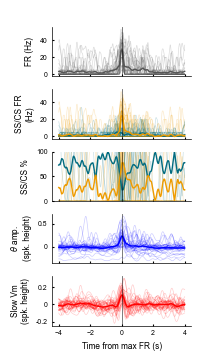

In [10]:
example_idx = 2  # 0-based index (default: 3rd entry)
plot_example = True
smooth_example = True
smooth_window = 100
plot_trials = True  # NEW: Option to plot each trial
trial_alpha = 0.2   # Transparency for individual trial lines
trial_linewidth = 0.5  # Line width for individual trials

from matplotlib.ticker import FuncFormatter
from scipy import signal

def _fmt_two_decimals(x, _):
    return f"{x:.2f}".rstrip("0").rstrip(".")

def _smooth_boxcar(trace, win=5):
    arr = np.asarray(trace, dtype=float)
    if win <= 1:
        return arr
    kernel = np.ones(win, dtype=float)
    valid = np.isfinite(arr).astype(float)
    arr_filled = np.where(np.isfinite(arr), arr, 0.0)
    smoothed = np.convolve(arr_filled, kernel, mode="same")
    counts = np.convolve(valid, kernel, mode="same")
    with np.errstate(invalid="ignore", divide="ignore"):
        smoothed = np.where(counts > 0, smoothed / counts, np.nan)
    return smoothed

def _compute_trial_stacks_for_cell(cell_idx, PC_output_all, traces, x_neural, y_neural, speed, spikes, 
                                    all_spikes, refined_SS, all_CS_spikes, frame_rate, 
                                    pf_center_window_sec, theta_freqs, slow_freqs,
                                    speed_threshold, min_duration_ms, place_field_threshold, 
                                    min_distance_cm, clear_traversal, session_start_frames,
                                    session_indices, bad_masks):
    """Compute trial-level stacks for a single cell, centered by max firing rate."""
    from utils.GRC_helpers import find_place_field_traversals, bandpass_filter, lowpass_filter, interpolate_nan_segment
    
    analysis = PC_output_all[cell_idx]
    if not analysis.get('is_place_cell', False):
        return None
    
    trace = traces[cell_idx]
    trace = interpolate_nan_segment(trace)
    theta_vm = bandpass_filter(trace, theta_freqs[0], theta_freqs[1], frame_rate, order=5)
    slow_vm = lowpass_filter(trace, slow_freqs, frame_rate, order=5)
    
    traversal_epochs, place_field_mask, rate_map, pf_bins, traversal_types = find_place_field_traversals(
        x_neural, y_neural, spikes, speed, frame_rate, cell_idx,
        analysis=analysis,
        speed_threshold=speed_threshold,
        min_duration_ms=min_duration_ms,
        place_field_threshold=place_field_threshold,
        min_distance_cm=min_distance_cm,
        clear_traversal=clear_traversal,
        return_traversal_types=True,
    )
    
    if len(traversal_epochs) == 0:
        return None
    
    # Get valid epochs (filter by session if needed)
    padding_frames = int(pf_center_window_sec * frame_rate)
    bad_mask = None
    if bad_masks is not None and cell_idx < len(bad_masks):
        bad_mask = np.asarray(bad_masks[cell_idx])
        if bad_mask.dtype != bool:
            if bad_mask.ndim == 1 and bad_mask.size == len(trace):
                bad_mask = bad_mask.astype(bool)
            else:
                bad_indices = np.asarray(bad_mask, dtype=int)
                bad_indices = bad_indices[(bad_indices >= 0) & (bad_indices < len(trace))]
                bad_mask = np.zeros(len(trace), dtype=bool)
                bad_mask[bad_indices] = True
        if bad_mask.shape[0] != len(trace):
            bad_mask = None
    
    epochs_to_plot = traversal_epochs
    if session_indices is not None and session_start_frames is not None:
        session_start_frames_arr = np.asarray(session_start_frames, dtype=int)
        session_start_frames_arr = session_start_frames_arr[np.argsort(session_start_frames_arr)]
        epochs_filtered = []
        for epoch_start, epoch_end in epochs_to_plot:
            session_idx = np.searchsorted(session_start_frames_arr, epoch_start, side="right") - 1
            if session_idx in session_indices:
                epochs_filtered.append((epoch_start, epoch_end))
        epochs_to_plot = epochs_filtered
    
    valid_epochs = []
    for epoch_start, epoch_end in epochs_to_plot:
        start_idx = epoch_start - padding_frames
        end_idx = epoch_end + padding_frames
        if start_idx < 0 or end_idx >= len(trace):
            continue
        if bad_mask is not None and np.any(bad_mask[start_idx:end_idx]):
            continue
        valid_epochs.append((epoch_start, epoch_end))
    
    if len(valid_epochs) == 0:
        return None
    
    # Get spike indices for this cell
    all_spike_indices = np.asarray(all_spikes[cell_idx], dtype=int)
    ss_indices = np.asarray(refined_SS[cell_idx], dtype=int)
    cs_indices = np.asarray(all_CS_spikes[cell_idx], dtype=int)
    
    # Compute IFR
    firing_rate_bin_ms = 100
    firing_rate_smooth_ms = 50
    
    def _compute_ifr(spike_indices):
        if spike_indices is None or len(spike_indices) == 0:
            return None
        spike_indices = spike_indices[(spike_indices >= 0) & (spike_indices < len(trace))]
        if spike_indices.size == 0:
            return None
        spike_train = np.zeros(len(trace), dtype=float)
        spike_train[spike_indices] = 1.0
        bin_frames = max(1, int(round(firing_rate_bin_ms / 1000 * frame_rate)))
        bin_kernel = np.ones(bin_frames, dtype=float) / bin_frames
        ifr = np.convolve(spike_train, bin_kernel, mode="same") * frame_rate
        smooth_frames = max(1, int(round(firing_rate_smooth_ms / 1000 * frame_rate)))
        if smooth_frames > 1:
            smooth_kernel = np.ones(smooth_frames, dtype=float) / smooth_frames
            ifr = np.convolve(ifr, smooth_kernel, mode="same")
        return ifr
    
    ifr = _compute_ifr(all_spike_indices)
    ifr_ss = _compute_ifr(ss_indices)
    ifr_cs = _compute_ifr(cs_indices)
    
    # Compute max rate center indices for each trial
    max_rate_center_indices = []
    trials_with_spikes = []
    for epoch_start, epoch_end in valid_epochs:
        max_rate_idx = None
        has_spikes = False
        if ifr is not None:
            spikes_in_epoch = (all_spike_indices >= epoch_start) & (all_spike_indices < epoch_end)
            has_spikes = np.any(spikes_in_epoch)
            if has_spikes:
                ifr_segment = ifr[epoch_start:epoch_end]
                if len(ifr_segment) > 0 and np.any(np.isfinite(ifr_segment)):
                    max_rel_idx = np.nanargmax(ifr_segment)
                    max_rate_idx = epoch_start + max_rel_idx
        max_rate_center_indices.append(max_rate_idx)
        trials_with_spikes.append(has_spikes)
    
    # Build stacks
    window_frames = int(round(pf_center_window_sec * frame_rate))
    avg_len = window_frames * 2 + 1
    time_rel_local = np.arange(-window_frames, window_frames + 1) / frame_rate
    
    theta_amp = np.abs(signal.hilbert(theta_vm))
    
    n_valid_trials = sum(trials_with_spikes)
    if n_valid_trials == 0:
        return None
    
    theta_stack = []
    slow_stack = []
    rate_stack = []
    ss_rate_stack = []
    cs_rate_stack = []
    ss_pct_stack = []
    cs_pct_stack = []
    
    baseline_start_offset = int(round(2.0 * frame_rate))
    baseline_end_offset = int(round(1.0 * frame_rate))
    
    for i, (center_idx, (epoch_start, _)) in enumerate(zip(max_rate_center_indices, valid_epochs)):
        if not trials_with_spikes[i]:
            continue
        if center_idx is None:
            continue
        
        # Baseline
        base_start = max(epoch_start - baseline_start_offset, 0)
        base_end = max(epoch_start - baseline_end_offset, 0)
        baseline_theta = np.nanmean(theta_amp[base_start:base_end]) if base_end > base_start else np.nan
        baseline_slow = np.nanmean(slow_vm[base_start:base_end]) if base_end > base_start else np.nan
        
        start_idx = max(center_idx - window_frames, 0)
        end_idx = min(center_idx + window_frames + 1, len(theta_vm))
        if end_idx <= start_idx:
            continue
        
        left_pad = (center_idx - window_frames) - start_idx
        right_pad = (center_idx + window_frames + 1) - end_idx
        write_start = max(0, left_pad)
        write_end = avg_len - max(0, right_pad)
        
        # Initialize trial arrays
        theta_trial = np.full(avg_len, np.nan)
        slow_trial = np.full(avg_len, np.nan)
        rate_trial = np.full(avg_len, np.nan)
        ss_rate_trial = np.full(avg_len, np.nan)
        cs_rate_trial = np.full(avg_len, np.nan)
        ss_pct_trial = np.full(avg_len, np.nan)
        cs_pct_trial = np.full(avg_len, np.nan)
        
        theta_segment = theta_amp[start_idx:end_idx].copy()
        slow_segment = slow_vm[start_idx:end_idx].copy()
        if np.isfinite(baseline_theta):
            theta_segment = theta_segment - baseline_theta
        if np.isfinite(baseline_slow):
            slow_segment = slow_segment - baseline_slow
        
        theta_trial[write_start:write_end] = theta_segment
        slow_trial[write_start:write_end] = slow_segment
        
        if ifr is not None:
            rate_trial[write_start:write_end] = ifr[start_idx:end_idx]
        if ifr_ss is not None:
            ss_rate_trial[write_start:write_end] = ifr_ss[start_idx:end_idx]
        if ifr_cs is not None:
            cs_rate_trial[write_start:write_end] = ifr_cs[start_idx:end_idx]
        
        if ifr_ss is not None and ifr_cs is not None:
            ss_seg = ifr_ss[start_idx:end_idx]
            cs_seg = ifr_cs[start_idx:end_idx]
            denom = ss_seg + cs_seg
            valid_denom = np.isfinite(denom) & (denom > 0)
            ss_pct_seg = np.where(valid_denom, 100.0 * ss_seg / denom, np.nan)
            cs_pct_seg = np.where(valid_denom, 100.0 * cs_seg / denom, np.nan)
            ss_pct_trial[write_start:write_end] = ss_pct_seg
            cs_pct_trial[write_start:write_end] = cs_pct_seg
        
        theta_stack.append(theta_trial)
        slow_stack.append(slow_trial)
        rate_stack.append(rate_trial)
        ss_rate_stack.append(ss_rate_trial)
        cs_rate_stack.append(cs_rate_trial)
        ss_pct_stack.append(ss_pct_trial)
        cs_pct_stack.append(cs_pct_trial)
    
    return {
        'theta_stack': np.array(theta_stack),
        'slow_stack': np.array(slow_stack),
        'rate_stack': np.array(rate_stack),
        'ss_rate_stack': np.array(ss_rate_stack),
        'cs_rate_stack': np.array(cs_rate_stack),
        'ss_pct_stack': np.array(ss_pct_stack),
        'cs_pct_stack': np.array(cs_pct_stack),
        'time_rel': time_rel_local,
        'n_trials': len(theta_stack),
    }

if plot_example and len(pf_centered_list) > 0:
    idx = min(example_idx, len(pf_centered_list) - 1)
    entry = pf_centered_list[idx]
    cell_idx_example = entry.get('cell_idx')
    
    theta = entry.get('theta_mean')
    slow = entry.get('slow_mean')
    rate = entry.get('rate_mean')
    ss_rate = entry.get('ss_rate_mean')
    cs_rate = entry.get('cs_rate_mean')
    ss_pct = entry.get('ss_pct_mean')
    cs_pct = entry.get('cs_pct_mean')
    
    # Compute trial-level data if requested
    trial_stacks = None
    if plot_trials and cell_idx_example is not None:
        trial_stacks = _compute_trial_stacks_for_cell(
            cell_idx_example, PC_output_all, traces, x_neural, y_neural, speed, spikes,
            all_spikes, refined_SS, all_CS_spikes, frame_rate,
            pf_center_window_sec, theta_freqs, slow_freqs,
            speed_threshold, min_duration_ms, place_field_threshold,
            min_distance_cm, clear_traversal, session_start_frames,
            session_indices, bad_masks
        )

    if rate is not None and len(rate) == len(time_rel):
        rate = np.asarray(rate, dtype=float)
    else:
        rate = None

    if ss_rate is not None and len(ss_rate) == len(time_rel):
        ss_rate = np.asarray(ss_rate, dtype=float)
    else:
        ss_rate = None

    if cs_rate is not None and len(cs_rate) == len(time_rel):
        cs_rate = np.asarray(cs_rate, dtype=float)
    else:
        cs_rate = None

    if ss_pct is not None and len(ss_pct) == len(time_rel):
        ss_pct = np.asarray(ss_pct, dtype=float)
    else:
        ss_pct = None

    if cs_pct is not None and len(cs_pct) == len(time_rel):
        cs_pct = np.asarray(cs_pct, dtype=float)
    else:
        cs_pct = None

    if ss_pct is None or cs_pct is None:
        if ss_rate is not None and cs_rate is not None:
            denom = ss_rate + cs_rate
            valid = np.isfinite(denom) & (denom > 0)
            ss_pct = np.where(valid, 100.0 * ss_rate / denom, np.nan)
            cs_pct = np.where(valid, 100.0 * cs_rate / denom, np.nan)
        else:
            ss_pct = None
            cs_pct = None

    if smooth_example:
        if theta is not None and len(theta) == len(time_rel):
            theta = _smooth_boxcar(theta, smooth_window)
        if slow is not None and len(slow) == len(time_rel):
            slow = _smooth_boxcar(slow, smooth_window)
        if rate is not None and len(rate) == len(time_rel):
            rate = _smooth_boxcar(rate, smooth_window)
        if ss_rate is not None and len(ss_rate) == len(time_rel):
            ss_rate = _smooth_boxcar(ss_rate, smooth_window)
        if cs_rate is not None and len(cs_rate) == len(time_rel):
            cs_rate = _smooth_boxcar(cs_rate, smooth_window)
        if ss_pct is not None and len(ss_pct) == len(time_rel):
            ss_pct = _smooth_boxcar(ss_pct, smooth_window)
        if cs_pct is not None and len(cs_pct) == len(time_rel):
            cs_pct = _smooth_boxcar(cs_pct, smooth_window)

    fig, axes = plt.subplots(5, 1, figsize=(2, 3.6), sharex=True)

    # Plot individual trials first (behind the mean)
    if plot_trials and trial_stacks is not None:
        time_rel_trials = trial_stacks['time_rel']
        for i in range(trial_stacks['n_trials']):
            # Rate
            trial_rate = trial_stacks['rate_stack'][i]
            if smooth_example:
                trial_rate = _smooth_boxcar(trial_rate, smooth_window)
            axes[0].plot(time_rel_trials, trial_rate, color='#555555', 
                        linewidth=trial_linewidth, alpha=trial_alpha)
            # SS/CS rate
            trial_ss = trial_stacks['ss_rate_stack'][i]
            trial_cs = trial_stacks['cs_rate_stack'][i]
            if smooth_example:
                trial_ss = _smooth_boxcar(trial_ss, smooth_window)
                trial_cs = _smooth_boxcar(trial_cs, smooth_window)
            axes[1].plot(time_rel_trials, trial_ss, color='#026C80',
                        linewidth=trial_linewidth, alpha=trial_alpha)
            axes[1].plot(time_rel_trials, trial_cs, color='#EE9B00',
                        linewidth=trial_linewidth, alpha=trial_alpha)
            # SS/CS pct
            trial_ss_pct = trial_stacks['ss_pct_stack'][i]
            trial_cs_pct = trial_stacks['cs_pct_stack'][i]
            if smooth_example:
                trial_ss_pct = _smooth_boxcar(trial_ss_pct, smooth_window)
                trial_cs_pct = _smooth_boxcar(trial_cs_pct, smooth_window)
            axes[2].plot(time_rel_trials, trial_ss_pct, color='#026C80',
                        linewidth=trial_linewidth, alpha=trial_alpha)
            axes[2].plot(time_rel_trials, trial_cs_pct, color='#EE9B00',
                        linewidth=trial_linewidth, alpha=trial_alpha)
            # Theta
            trial_theta = trial_stacks['theta_stack'][i]
            if smooth_example:
                trial_theta = _smooth_boxcar(trial_theta, smooth_window)
            axes[3].plot(time_rel_trials, trial_theta, color='blue',
                        linewidth=trial_linewidth, alpha=trial_alpha)
            # Slow
            trial_slow = trial_stacks['slow_stack'][i]
            if smooth_example:
                trial_slow = _smooth_boxcar(trial_slow, smooth_window)
            axes[4].plot(time_rel_trials, trial_slow, color='red',
                        linewidth=trial_linewidth, alpha=trial_alpha)
        print(f"Plotted {trial_stacks['n_trials']} individual trials")

    # Plot means on top
    if rate is not None and len(rate) == len(time_rel):
        axes[0].plot(time_rel, rate, color='#555555', linewidth=1.0)
        axes[0].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[0].set_ylabel('FR (Hz)', fontsize=6, fontname='Arial')
    else:
        axes[0].text(
            0.5, 0.5, 'No FR data', transform=axes[0].transAxes,
            ha='center', va='center', fontsize=6, fontname='Arial'
        )
        axes[0].set_ylabel('FR (Hz)', fontsize=6, fontname='Arial')

    if (ss_rate is not None and len(ss_rate) == len(time_rel)) or (cs_rate is not None and len(cs_rate) == len(time_rel)):
        if ss_rate is not None:
            axes[1].plot(time_rel, ss_rate, color='#026C80', linewidth=1.0)
        if cs_rate is not None:
            axes[1].plot(time_rel, cs_rate, color='#EE9B00', linewidth=1.0)
        axes[1].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[1].set_ylabel('SS/CS FR\n(Hz)', fontsize=6, fontname='Arial')
    else:
        axes[1].text(
            0.5, 0.5, 'No SS/CS FR data', transform=axes[1].transAxes,
            ha='center', va='center', fontsize=6, fontname='Arial'
        )
        axes[1].set_ylabel('SS/CS FR\n(Hz)', fontsize=6, fontname='Arial')

    if (ss_pct is not None and len(ss_pct) == len(time_rel)) or (cs_pct is not None and len(cs_pct) == len(time_rel)):
        if ss_pct is not None:
            axes[2].plot(time_rel, ss_pct, color='#026C80', linewidth=1.0)
        if cs_pct is not None:
            axes[2].plot(time_rel, cs_pct, color='#EE9B00', linewidth=1.0)
        axes[2].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')
    else:
        axes[2].text(
            0.5, 0.5, 'No SS/CS % data', transform=axes[2].transAxes,
            ha='center', va='center', fontsize=6, fontname='Arial'
        )
        axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')

    if theta is not None and len(theta) == len(time_rel):
        axes[3].plot(time_rel, theta, color='blue', linewidth=1.0)
        axes[3].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[3].set_ylabel('$\\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')
    else:
        axes[3].text(
            0.5, 0.5, 'No theta data', transform=axes[3].transAxes,
            ha='center', va='center', fontsize=6, fontname='Arial'
        )
        axes[3].set_ylabel('$\\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')

    if slow is not None and len(slow) == len(time_rel):
        axes[4].plot(time_rel, slow, color='red', linewidth=1.0)
        axes[4].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')
    else:
        axes[4].text(
            0.5, 0.5, 'No slow data', transform=axes[4].transAxes,
            ha='center', va='center', fontsize=6, fontname='Arial'
        )
        axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')

    axes[4].set_xlabel('Time from max FR (s)', fontsize=6, fontname='Arial')
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=5)
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
        for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            label.set_fontname('Arial')

    axes[2].set_ylim(0, 100)
    # axes[3].set_ylim(-0.03, 0.07)
    # axes[4].set_ylim(-0.025, 0.06)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    example_out_path = os.path.join(
        figure_save_folder,
        f'pf_centered_example_cell{idx + 1}.svg',
    )
    fig.savefig(example_out_path, dpi=300)
    print(f"Saved example plot to {example_out_path}")
    print(f"Plotted example cell index {idx} (cell_idx={entry.get('cell_idx')})")

    plt.show()
else:
    print('No PF-centered averages available for example plot.')

Saved grand average to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/pf_centered_grand_avg.svg
N cells included: theta=5 slow=5 FR=5 SS/CS FR=4 SS/CS %=4


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_8342/4276708061.py:100: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_rate / denom, np.nan)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_8342/4276708061.py:101: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_rate / denom, np.nan)


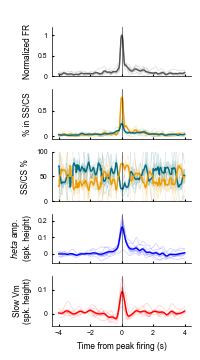

In [11]:
if len(pf_centered_list) > 0:
    theta_stack = [
        entry['theta_mean']
        for entry in pf_centered_list
        if entry.get('theta_mean') is not None and len(entry['theta_mean']) == len(time_rel)
    ]
    slow_stack = [
        entry['slow_mean']
        for entry in pf_centered_list
        if entry.get('slow_mean') is not None and len(entry['slow_mean']) == len(time_rel)
    ]
    rate_stack = []
    ss_cs_pairs = []
    zero_idx = len(time_rel) // 2
    for entry in pf_centered_list:
        rate = entry.get('rate_mean')
        if rate is not None and len(rate) == len(time_rel):
            rate = np.asarray(rate, dtype=float)
            rate_stack.append(rate)
        else:
            rate = None
        ss_rate = entry.get('ss_rate_mean')
        cs_rate = entry.get('cs_rate_mean')
        if ss_rate is None or cs_rate is None or rate is None:
            continue
        if len(ss_rate) != len(time_rel) or len(cs_rate) != len(time_rel):
            continue
        ss_rate = np.asarray(ss_rate, dtype=float)
        cs_rate = np.asarray(cs_rate, dtype=float)
        if not np.any(np.isfinite(cs_rate)) or np.nanmax(cs_rate) <= 0:
            continue
        ss_cs_pairs.append((ss_rate, cs_rate, rate))

    plot_individual = True
    smooth_individual = True

    def _smooth_boxcar(trace, win=5):
        arr = np.asarray(trace, dtype=float)
        if win <= 1:
            return arr
        kernel = np.ones(win, dtype=float)
        valid = np.isfinite(arr).astype(float)
        arr_filled = np.where(np.isfinite(arr), arr, 0.0)
        smoothed = np.convolve(arr_filled, kernel, mode="same")
        counts = np.convolve(valid, kernel, mode="same")
        with np.errstate(invalid="ignore", divide="ignore"):
            smoothed = np.where(counts > 0, smoothed / counts, np.nan)
        return smoothed

    def _prep_stack(stack):
        if not smooth_individual:
            return stack
        return [_smooth_boxcar(trace, smooth_window) for trace in stack]

    def _prep_pair_stack(pair_stack):
        if not smooth_individual:
            return pair_stack
        smoothed = []
        for ss_rate, cs_rate, total_rate in pair_stack:
            smoothed.append((
                _smooth_boxcar(ss_rate, smooth_window),
                _smooth_boxcar(cs_rate, smooth_window),
                _smooth_boxcar(total_rate, smooth_window),
            ))
        return smoothed

    def _normalize_rate(trace):
        if trace is None or len(trace) != len(time_rel):
            return None
        trace = np.asarray(trace, dtype=float)
        if not np.any(np.isfinite(trace)):
            return None
        norm_val = trace[zero_idx]
        if not np.isfinite(norm_val) or norm_val == 0:
            peak = np.nanmax(trace)
            if not np.isfinite(peak) or peak == 0:
                return None
            norm_val = peak
        return trace / norm_val

    theta_stack_use = _prep_stack(theta_stack)
    slow_stack_use = _prep_stack(slow_stack)
    rate_stack_use = [_normalize_rate(rate) for rate in _prep_stack(rate_stack)]
    rate_stack_use = [rate for rate in rate_stack_use if rate is not None]

    ss_norm_stack_use = []
    cs_norm_stack_use = []
    ss_percent_stack = []
    cs_percent_stack = []
    for ss_rate, cs_rate, total_rate in _prep_pair_stack(ss_cs_pairs):
        denom_total = total_rate[zero_idx]
        if np.isfinite(denom_total) and denom_total > 0:
            ss_norm = ss_rate / denom_total
            cs_norm = cs_rate / denom_total
            if np.any(np.isfinite(ss_norm)):
                ss_norm_stack_use.append(ss_norm)
                cs_norm_stack_use.append(cs_norm)
        denom = ss_rate + cs_rate
        valid = np.isfinite(denom) & (denom > 0)
        ss_pct = np.where(valid, 100.0 * ss_rate / denom, np.nan)
        cs_pct = np.where(valid, 100.0 * cs_rate / denom, np.nan)
        if np.any(np.isfinite(ss_pct)):
            ss_percent_stack.append(ss_pct)
            cs_percent_stack.append(cs_pct)

    def mean_sem(stack):
        if not stack:
            return None, None
        arr = np.vstack(stack)
        mean = np.nanmean(arr, axis=0)
        count = np.sum(np.isfinite(arr), axis=0)
        std = np.nanstd(arr, axis=0, ddof=0)
        sem = np.where(count > 0, std / np.sqrt(count), np.nan)
        return mean, sem

    from matplotlib.ticker import FuncFormatter

    def _fmt_two_decimals(x, _):
        return f"{x:.2f}".rstrip("0").rstrip(".")

    theta_grand, theta_sem = mean_sem(theta_stack_use)
    slow_grand, slow_sem = mean_sem(slow_stack_use)
    rate_grand, rate_sem = mean_sem(rate_stack_use)
    ss_norm_grand, ss_norm_sem = mean_sem(ss_norm_stack_use)
    cs_norm_grand, cs_norm_sem = mean_sem(cs_norm_stack_use)
    ss_pct_grand, ss_pct_sem = mean_sem(ss_percent_stack)
    cs_pct_grand, cs_pct_sem = mean_sem(cs_percent_stack)

    fig, axes = plt.subplots(5, 1, figsize=(2, 3.6), sharex=True)
    if rate_grand is not None:
        if plot_individual:
            for rate in rate_stack_use:
                axes[0].plot(time_rel, rate, color='#555555', linewidth=0.5, alpha=0.2)
        axes[0].plot(time_rel, rate_grand, color='#555555', linewidth=1.0)
        if rate_sem is not None:
            axes[0].fill_between(
                time_rel,
                rate_grand - rate_sem,
                rate_grand + rate_sem,
                color='#555555',
                alpha=0.2,
                linewidth=0,
            )
        axes[0].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[0].set_ylabel('Normalized FR', fontsize=6, fontname='Arial')
    else:
        axes[0].text(0.5, 0.5, 'No FR data', transform=axes[0].transAxes,
                    ha='center', va='center', fontsize=6, fontname='Arial')
        axes[0].set_ylabel('Normalized FR', fontsize=6, fontname='Arial')

    if ss_norm_grand is not None or cs_norm_grand is not None:
        if plot_individual:
            for ss_norm in ss_norm_stack_use:
                axes[1].plot(time_rel, ss_norm, color='#026C80', linewidth=0.5, alpha=0.2)
            for cs_norm in cs_norm_stack_use:
                axes[1].plot(time_rel, cs_norm, color='#EE9B00', linewidth=0.5, alpha=0.2)
        if cs_norm_grand is not None:
            axes[1].plot(time_rel, cs_norm_grand, color='#EE9B00', linewidth=1.0)
            if cs_norm_sem is not None:
                axes[1].fill_between(
                    time_rel,
                    cs_norm_grand - cs_norm_sem,
                    cs_norm_grand + cs_norm_sem,
                    color='#EE9B00',
                    alpha=0.2,
                    linewidth=0,
                )
        if ss_norm_grand is not None:
            axes[1].plot(time_rel, ss_norm_grand, color='#026C80', linewidth=1.0)
            if ss_norm_sem is not None:
                axes[1].fill_between(
                    time_rel,
                    ss_norm_grand - ss_norm_sem,
                    ss_norm_grand + ss_norm_sem,
                    color='#026C80',
                    alpha=0.2,
                    linewidth=0,
                )

        axes[1].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[1].set_ylabel('% in SS/CS', fontsize=6, fontname='Arial')
    else:
        axes[1].text(0.5, 0.5, 'No SS/CS FR data', transform=axes[1].transAxes,
                    ha='center', va='center', fontsize=6, fontname='Arial')
        axes[1].set_ylabel('% in SS/CS', fontsize=6, fontname='Arial')
    if ss_pct_grand is not None or cs_pct_grand is not None:
        if plot_individual:
            for trace in ss_percent_stack:
                axes[2].plot(time_rel, trace, color='#026C80', linewidth=0.5, alpha=0.2)
            for trace in cs_percent_stack:
                axes[2].plot(time_rel, trace, color='#EE9B00', linewidth=0.5, alpha=0.2)
        if ss_pct_grand is not None:
            axes[2].plot(time_rel, ss_pct_grand, color='#026C80', linewidth=1.0)
            if ss_pct_sem is not None:
                axes[2].fill_between(
                    time_rel,
                    ss_pct_grand - ss_pct_sem,
                    ss_pct_grand + ss_pct_sem,
                    color='#026C80',
                    alpha=0.2,
                    linewidth=0,
                )
        if cs_pct_grand is not None:
            axes[2].plot(time_rel, cs_pct_grand, color='#EE9B00', linewidth=1.0)
            if cs_pct_sem is not None:
                axes[2].fill_between(
                    time_rel,
                    cs_pct_grand - cs_pct_sem,
                    cs_pct_grand + cs_pct_sem,
                    color='#EE9B00',
                    alpha=0.2,
                    linewidth=0,
                )
        axes[2].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')
    else:
        axes[2].text(0.5, 0.5, 'No SS/CS % data', transform=axes[2].transAxes,
                    ha='center', va='center', fontsize=6, fontname='Arial')
        axes[2].set_ylabel('SS/CS %', fontsize=6, fontname='Arial')

    if theta_grand is not None:
        if plot_individual:
            for theta in theta_stack_use:
                axes[3].plot(time_rel, theta, color='blue', linewidth=0.5, alpha=0.2)
        axes[3].plot(time_rel, theta_grand, color='blue', linewidth=1.0)
        if theta_sem is not None:
            axes[3].fill_between(
                time_rel,
                theta_grand - theta_sem,
                theta_grand + theta_sem,
                color='blue',
                alpha=0.2,
                linewidth=0,
            )
        axes[3].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[3].set_ylabel('$\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')
    else:
        axes[3].text(0.5, 0.5, 'No theta data', transform=axes[3].transAxes,
                    ha='center', va='center', fontsize=6, fontname='Arial')
        axes[3].set_ylabel('$\theta$ amp.\n(spk. height)', fontsize=6, fontname='Arial')

    if slow_grand is not None:
        if plot_individual:
            for slow in slow_stack_use:
                axes[4].plot(time_rel, slow, color='red', linewidth=0.5, alpha=0.2)
        axes[4].plot(time_rel, slow_grand, color='red', linewidth=1.0)
        if slow_sem is not None:
            axes[4].fill_between(
                time_rel,
                slow_grand - slow_sem,
                slow_grand + slow_sem,
                color='red',
                alpha=0.2,
                linewidth=0,
            )
        axes[4].axvline(0, color='black', linewidth=0.6, alpha=0.6)
        axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')
    else:
        axes[4].text(0.5, 0.5, 'No slow data', transform=axes[4].transAxes,
                    ha='center', va='center', fontsize=6, fontname='Arial')
        axes[4].set_ylabel('Slow Vm\n(spk. height)', fontsize=6, fontname='Arial')

    axes[4].set_xlabel('Time from peak firing (s)', fontsize=6, fontname='Arial')
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=5)
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
        for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            label.set_fontname('Arial')
    # fig.suptitle(
    #     f'Grand average (n={len(pf_centered_list)})',
    #     fontsize=6,
    #     fontname='Arial',
    #     x=0.5,
    # )
    axes[0].set_ylim(0, 1.2)
    axes[2].set_ylim(0, 100)
    # axes[3].set_ylim(-0.02, 0.1)
    # axes[4].set_ylim(-0.025, 0.06)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    grand_out_path = os.path.join(
        figure_save_folder,
        f'pf_centered_grand_avg.svg',
    )
    plt.rcParams['svg.fonttype'] = 'none'
    fig.savefig(grand_out_path, dpi=300)
    print(f'Saved grand average to {grand_out_path}')
    print(
        'N cells included:',
        f'theta={len(theta_stack_use)}',
        f'slow={len(slow_stack_use)}',
        f'FR={len(rate_stack_use)}',
        f'SS/CS FR={len(ss_norm_stack_use)}',
        f'SS/CS %={len(ss_percent_stack)}',
    )
    plt.show()
else:
    print('No PF-centered averages available for grand plot.')


# 2D subthreshold activity maps

In [32]:
# # Plot 2D map of theta and slow Vm amplitudes for each place cell

# theta_slow_save_dir = os.path.join(figure_save_folder, 'theta_slow_maps')
# os.makedirs(theta_slow_save_dir, exist_ok=True)

# for cell_idx, analysis in enumerate(PC_output_all):
#     if not analysis.get('is_place_cell', False):
#         continue
#     fig, axes, maps = plot_theta_slow_maps_by_state(
#         x_neural,
#         y_neural,
#         speed,
#         frame_rate,
#         traces,
#         analysis,
#         cell_idx,
#         theta_freqs=theta_freqs,
#         slow_freqs=slow_freqs,
#         speed_threshold=speed_threshold,
#         kernel_size=kernel_size,
#         filter_type='boxcar',
#         min_duration_s=min_duration_ms / 1000.0,
#         merge_gap_s=merge_gap_s,
#         smooth_sigma=2.0,
#         bad_timepoints=bad_masks if 'bad_masks' in globals() else None,
#         save_dir=theta_slow_save_dir,
#         show=True,
#     )
#     if fig is None:
#         continue
#     out_path = os.path.join(
#         theta_slow_save_dir,
#         f'theta_slow_maps_cell{cell_idx + 1}.svg',
#     )
#     fig.savefig(out_path, dpi=300)
#     print(f'Saved theta/slow maps for cell {cell_idx + 1} to {out_path}')



# CS shapes and metrics

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell1.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell2.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell3.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell4.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell6.svg
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell7.svg


/Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/utils/GRC_helpers.py:6053: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=5, frameon=False)


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PlaceCells/Figure3_SpikeShapes_PF_Cell9.svg
Saved spike shape data to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/spike_shapes_PF.pkl


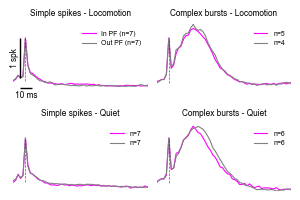

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PF_Grand.svg


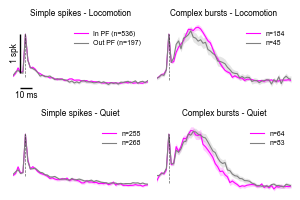

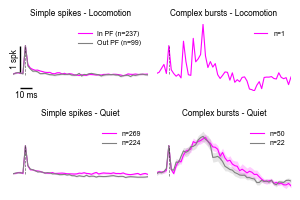

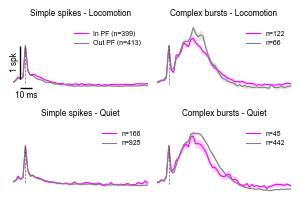

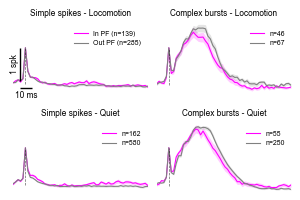

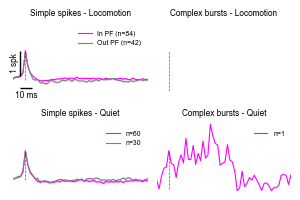

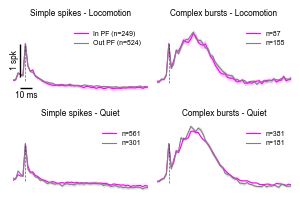

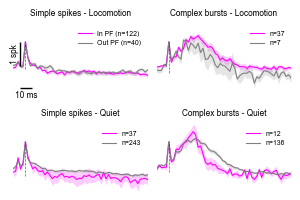

In [33]:
place_cell_indices = [
    i for i, analysis in enumerate(PC_output_all)
    if analysis.get('is_place_cell', False)
]
grand_stack = {
    'simple': {'run_in': [], 'run_out': [], 'rest_in': [], 'rest_out': []},
    'complex': {'run_in': [], 'run_out': [], 'rest_in': [], 'rest_out': []},
}
time_ms = None

figure_save_folder_spkshapes = os.path.join(figure_save_folder, 'SpikeShapes_PlaceCells')
os.makedirs(figure_save_folder_spkshapes, exist_ok=True)

if len(place_cell_indices) == 0:
    print('No place cells found for spike-shape plots.')
else:
    for cell_idx in place_cell_indices:
        spike_shape_fig, spike_shape_axes, spike_shape_data = plot_spike_shapes_by_pf(
            x_neural, y_neural, speed, frame_rate,
            traces, refined_SS, complex_bursts_dicts,
            all_CS_spikes=all_CS_spikes,
            analysis_list=PC_output_all,
            cell_indices=[cell_idx],
            speed_threshold=speed_threshold,
            kernel_size=kernel_size,
            filter_type="boxcar",
            min_duration_s=min_duration_s,
            merge_gap_s=merge_gap_s,
            show=False,
            return_data=True,
        )
        if time_ms is None:
            time_ms = spike_shape_data['time_ms']
        for spike_type in ['simple', 'complex']:
            for cond in ['run_in', 'run_out', 'rest_in', 'rest_out']:
                waves = spike_shape_data['shapes'][spike_type][cond]
                if len(waves) < 10:
                    grand_stack[spike_type][cond].append(
                        np.full_like(time_ms, np.nan, dtype=float)
                    )
                else:
                    mean_wave = np.nanmean(np.vstack(waves), axis=0)
                    grand_stack[spike_type][cond].append(mean_wave)

        spike_shape_out_path = os.path.join(
            figure_save_folder_spkshapes,
            f"Figure3_SpikeShapes_PF_Cell{cell_idx+1}.svg",
        )
        plt.rcParams["svg.fonttype"] = "none"
        spike_shape_fig.savefig(spike_shape_out_path, dpi=300)
        print(f"Saved to {spike_shape_out_path}")
        #plt.close(spike_shape_fig)

    if time_ms is not None:
        # Save spike shape data for cross-FOV pooling
        spike_shapes_out = os.path.join(data_folder, 'spike_shapes_PF.pkl')
        with open(spike_shapes_out, 'wb') as f:
            pickle.dump({
                'time_ms': time_ms,
                'grand_stack': grand_stack,
            }, f)
        print(f'Saved spike shape data to {spike_shapes_out}')

        grand_out_path = os.path.join(
            figure_save_folder,
            f"SpikeShapes_PF_Grand.svg",
        )
        plot_spike_shape_grand_average(
            time_ms,
            grand_stack,
            output_path=grand_out_path,
            show=True,
        )
        print(f"Saved to {grand_out_path}")
    else:
        print('No spike-shape data available for grand average.')

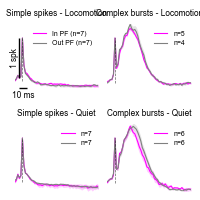

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeShapes_PF_Grand.svg


In [53]:
if time_ms is not None:
    grand_out_path = os.path.join(
        figure_save_folder,
        f"SpikeShapes_PF_Grand.svg",
    )
    plot_spike_shape_grand_average(
        time_ms,
        grand_stack,
        output_path=grand_out_path,
        fig_size=(2, 2),
        show=True,
    )
    print(f"Saved to {grand_out_path}")
else:
    print('No spike-shape data available for grand average.')


Locomotion SS rate (Hz) (paired t-test): n=7, stat=9.72, p=6.81e-05, shapiro_p=0.66
Locomotion CB rate (Hz) (paired t-test): n=5, stat=21.6, p=2.7e-05, shapiro_p=0.912
Locomotion CB prob. (paired t-test): n=5, stat=6.01, p=0.00387, shapiro_p=0.91
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeBurstRates_run.svg


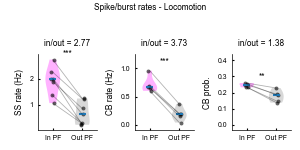

Quiet SS rate (Hz) (paired t-test): n=7, stat=3.2, p=0.0185, shapiro_p=0.785
Quiet CB rate (Hz) (paired t-test): n=6, stat=1.29, p=0.252, shapiro_p=0.991
Quiet CB prob. (paired t-test): n=6, stat=-1.18, p=0.29, shapiro_p=0.524
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/SpikeBurstRates_rest.svg


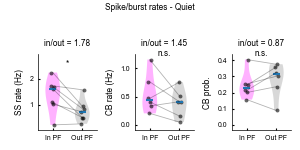

Saved rate metrics to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/spike_burst_rates_PF.pkl


In [42]:
conditions = ['run_in', 'run_out', 'rest_in', 'rest_out']
state_specs = [
    ('run', 'Locomotion'),
    ('rest', 'Quiet'),
]

min_cb_bursts_per_condition = 5
rate_metrics = {
    'simple_rate': {cond: [] for cond in conditions},
    'burst_rate': {cond: [] for cond in conditions},
    'burst_prob': {cond: [] for cond in conditions},
}
burst_counts = {cond: [] for cond in conditions}

for cell_idx, analysis in enumerate(PC_output_all):
    if not analysis.get('is_place_cell', False):
        continue
    if cell_idx >= len(complex_bursts_dicts) or cell_idx >= len(all_CS_spikes):
        continue
    if cell_idx >= len(refined_SS):
        continue

    params = analysis.get('params', {})
    width_real = params.get('width_real', 35.5)
    height_real = params.get('height_real', 20)
    bin_size = params.get('bin_size', 1.5)
    bins = [
        np.arange(0, width_real + bin_size, bin_size),
        np.arange(0, height_real + bin_size, bin_size),
    ]
    place_field_mask = np.asarray(analysis.get('place_field_mask', []), dtype=bool)
    if place_field_mask.size == 0 or not np.any(place_field_mask):
        continue

    valid_frames = (
        np.isfinite(x_neural)
        & np.isfinite(y_neural)
        & np.isfinite(speed)
    )
    bad_mask = None
    if bad_masks is not None and cell_idx < len(bad_masks):
        bad_mask = np.asarray(bad_masks[cell_idx])
        if bad_mask.dtype != bool:
            if bad_mask.ndim == 1 and bad_mask.size == len(speed):
                bad_mask = bad_mask.astype(bool)
            else:
                bad_mask = np.asarray(bad_mask, dtype=int)
                bad_mask = bad_mask[(bad_mask >= 0) & (bad_mask < len(speed))]
                bad_bool = np.zeros(len(speed), dtype=bool)
                bad_bool[bad_mask] = True
                bad_mask = bad_bool
        if bad_mask.shape[0] != len(speed):
            bad_mask = None
    if bad_mask is not None:
        valid_frames &= ~bad_mask
    inside_pf = positions_in_place_field(x_neural, y_neural, bins, place_field_mask)

    moving_mask = np.zeros(len(speed), dtype=bool)
    moving_idx = analysis.get('moving_indices', [])
    if moving_idx is not None and len(moving_idx) > 0:
        moving_mask[np.asarray(moving_idx, dtype=int)] = True
    else:
        moving_mask = (speed > speed_threshold) & valid_frames

    moving_mask &= valid_frames

    simple_events = np.asarray(refined_SS[cell_idx], dtype=int)
    simple_events = simple_events[(simple_events >= 0) & (simple_events < len(speed))]

    bursts = complex_bursts_dicts[cell_idx]
    starts = np.asarray(bursts.get('starts', []), dtype=int)
    ends = np.asarray(bursts.get('ends', []), dtype=int)
    cs_spikes = np.asarray(all_CS_spikes[cell_idx], dtype=int)
    cs_spikes = cs_spikes[(cs_spikes >= 0) & (cs_spikes < len(speed))]
    burst_events = []
    for start_idx, end_idx in zip(starts, ends):
        in_burst = cs_spikes[(cs_spikes >= start_idx) & (cs_spikes <= end_idx)]
        if in_burst.size == 0:
            continue
        burst_events.append(in_burst[0])
    burst_events = np.asarray(burst_events, dtype=int)

    cond_masks = {
        'run_in': moving_mask & inside_pf & valid_frames,
        'run_out': moving_mask & (~inside_pf) & valid_frames,
        'rest_in': (~moving_mask) & inside_pf & valid_frames,
        'rest_out': (~moving_mask) & (~inside_pf) & valid_frames,
    }

    for cond in conditions:
        mask = cond_masks[cond]
        time_s = np.sum(mask) / frame_rate
        if time_s <= 0:
            burst_counts[cond].append(0)
            rate_metrics['simple_rate'][cond].append(np.nan)
            rate_metrics['burst_rate'][cond].append(np.nan)
            rate_metrics['burst_prob'][cond].append(np.nan)
            continue

        simple_count = np.sum(mask[simple_events]) if simple_events.size > 0 else 0
        burst_count = np.sum(mask[burst_events]) if burst_events.size > 0 else 0
        total_events = simple_count + burst_count

        burst_counts[cond].append(burst_count)

        rate_metrics['simple_rate'][cond].append(simple_count / time_s)
        rate_metrics['burst_rate'][cond].append(burst_count / time_s)
        rate_metrics['burst_prob'][cond].append(
            (burst_count / total_events) if total_events > 0 else np.nan
        )

metric_specs = [
    ('simple_rate', 'SS rate (Hz)'),
    ('burst_rate', 'CB rate (Hz)'),
    ('burst_prob', 'CB prob.'),
]

from scipy import stats

def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

panel_w = 1.0
panel_h = 1.5
xlim = (0.5, 2.5)

def _global_ylim_from_vals(vals, pad_frac=0.08):
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        return None
    y_min = np.nanmin(finite)
    y_max = np.nanmax(finite)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

metric_ylim = {}
for metric_key, _ in metric_specs:
    all_vals = []
    for cond in conditions:
        arr = np.asarray(rate_metrics[metric_key][cond], dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            all_vals.append(finite)
    if all_vals:
        metric_ylim[metric_key] = _global_ylim_from_vals(np.concatenate(all_vals))
    else:
        metric_ylim[metric_key] = None

for state_key, state_label in state_specs:
    fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3, panel_h), sharex=True, sharey=False)
    conds = [f"{state_key}_in", f"{state_key}_out"]
    cond_labels = ['In PF', 'Out PF']

    counts_in = np.asarray(burst_counts[conds[0]], dtype=float)
    counts_out = np.asarray(burst_counts[conds[1]], dtype=float)
    if counts_in.size > 0 and counts_out.size > 0:
        pair_mask_cb = ~((counts_in < min_cb_bursts_per_condition) & (counts_out < min_cb_bursts_per_condition))
    else:
        pair_mask_cb = np.array([], dtype=bool)

    for ax, (metric_key, ylabel) in zip(axes, metric_specs):
        vals_in_raw = np.asarray(rate_metrics[metric_key][conds[0]], dtype=float)
        vals_out_raw = np.asarray(rate_metrics[metric_key][conds[1]], dtype=float)
        if metric_key in ('burst_rate', 'burst_prob') and pair_mask_cb.size > 0:
            vals_in = vals_in_raw[pair_mask_cb]
            vals_out = vals_out_raw[pair_mask_cb]
        else:
            vals_in = vals_in_raw
            vals_out = vals_out_raw
        mean_in = np.nanmean(vals_in) if np.any(np.isfinite(vals_in)) else np.nan
        mean_out = np.nanmean(vals_out) if np.any(np.isfinite(vals_out)) else np.nan
        if np.isfinite(mean_in) and np.isfinite(mean_out) and mean_out != 0:
            ratio_text = f"in/out = {mean_in / mean_out:.2f}"
        else:
            ratio_text = "in/out = n/a"
        ax.set_title(ratio_text, fontsize=6, fontname='Arial')

        plot_data = []
        for vals in [vals_in, vals_out]:
            finite = vals[np.isfinite(vals)]
            if finite.size == 0:
                finite = np.array([np.nan])
            plot_data.append(finite)

        parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
        for body in parts['bodies']:
            body.set_alpha(0.3)
        if len(parts['bodies']) >= 2:
            parts['bodies'][0].set_facecolor('magenta')
            parts['bodies'][1].set_facecolor('gray')
            parts['bodies'][0].set_edgecolor('none')
            parts['bodies'][1].set_edgecolor('none')

        n_pairs = min(len(vals_in), len(vals_out))
        for i in range(n_pairs):
            if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
                ax.plot(
                    [1, 2],
                    [vals_in[i], vals_out[i]],
                    color='black',
                    alpha=0.3,
                    linewidth=0.6,
                )

        p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
        sig_label = _sig_label(p_val)
        if np.isfinite(p_val):
            y_vals = np.concatenate([vals_in[np.isfinite(vals_in)], vals_out[np.isfinite(vals_out)]])
            if y_vals.size > 0:
                y_max = np.nanmax(y_vals)
                y_min = np.nanmin(y_vals)
                y_span = y_max - y_min if y_max != y_min else 1.0
                y_off = 0.08 * y_span
                y_star = y_max + y_off
                if metric_ylim[metric_key] is not None:
                    y0, y1 = metric_ylim[metric_key]
                    y_span_global = y1 - y0 if y1 != y0 else 1.0
                    y_star = min(y_star, y1 - 0.05 * y_span_global)
                ax.text(
                    1.5,
                    y_star,
                    sig_label,
                    ha='center',
                    va='bottom',
                    fontsize=6,
                    fontname='Arial',
                )
            print(
                f"{state_label} {ylabel} ({test_name}): n={n_valid}, "
                f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
            )
        else:
            print(f"{state_label} {ylabel}: n={n_valid} (insufficient valid pairs)")

        rng = np.random.default_rng(0)
        for idx, vals in enumerate([vals_in, vals_out], start=1):
            finite_mask = np.isfinite(vals)
            if not np.any(finite_mask):
                continue
            jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
            xs = idx + jitter
            ax.scatter(
                xs,
                vals[finite_mask],
                s=8,
                color='black',
                alpha=0.6,
                linewidths=0,
            )

        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            cond_labels,
            fontsize=5,
            fontname='Arial',
        )
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.tick_params(labelsize=5)
        ax.set_xlim(*xlim)
        if metric_ylim[metric_key] is not None:
            ax.set_ylim(*metric_ylim[metric_key])
        for label in list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f"Spike/burst rates - {state_label}",
        fontsize=6,
        fontname='Arial',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    out_path = os.path.join(
        figure_save_folder,
        f"SpikeBurstRates_{state_key}.svg",
    )
    fig.savefig(out_path, dpi=300)
    print(f"Saved to {out_path}")
    plt.show()

# Save rate metrics for pooling
rate_metrics_out = os.path.join(data_folder, 'spike_burst_rates_PF.pkl')
with open(rate_metrics_out, 'wb') as f:
    pickle.dump({
        'rate_metrics': rate_metrics,
        'burst_counts': burst_counts,
        'conditions': conditions,
        'min_cb_bursts_per_condition': min_cb_bursts_per_condition,
    }, f)
print(f'Saved rate metrics to {rate_metrics_out}')

Locomotion Spks./burst (complex wilcoxon): n=5, stat=6, p=0.812, shapiro_p=0.0307
Locomotion Peak amp (complex paired t-test): n=5, stat=-0.781, p=0.478, shapiro_p=0.78
Locomotion Duration (ms) (complex paired t-test): n=5, stat=-1.26, p=0.275, shapiro_p=0.466
Locomotion AUC (complex paired t-test): n=5, stat=-2.81, p=0.0483, shapiro_p=0.404
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/ComplexBurstMetrics_run.svg


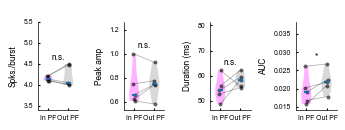

Quiet Spks./burst (complex wilcoxon): n=6, stat=6, p=0.438, shapiro_p=0.003
Quiet Peak amp (complex paired t-test): n=6, stat=-1.84, p=0.125, shapiro_p=0.76
Quiet Duration (ms) (complex paired t-test): n=6, stat=-4.48, p=0.0065, shapiro_p=0.838
Quiet AUC (complex paired t-test): n=6, stat=-2.55, p=0.0513, shapiro_p=0.54
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/ComplexBurstMetrics_rest.svg


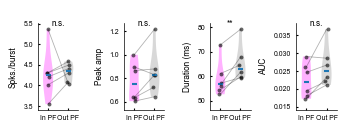

Saved burst metrics to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/burst_metrics_PF.pkl


In [60]:
# Complex (and optional simple) burst metrics by PF and locomotion state (from burst_metrics)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

include_simple_bursts = False

conditions = ['run_in', 'run_out', 'rest_in', 'rest_out']
condition_labels = ['In PF', 'Out PF']

min_bursts_per_condition = 5

metric_specs = [
    ('n_spikes', 'Spks./burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

metric_data = {
    'complex': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs},
    'simple': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs},
}
cond_counts = {
    'complex': {cond: [] for cond in conditions},
    'simple': {cond: [] for cond in conditions},
}

for cell_idx, analysis in enumerate(PC_output_all):
    if not analysis.get('is_place_cell', False):
        continue
    if cell_idx >= len(burst_metrics):
        continue

    bursts = burst_metrics[cell_idx]
    if not bursts:
        continue

    params = analysis.get('params', {})
    width_real = params.get('width_real', 35.5)
    height_real = params.get('height_real', 20)
    bin_size = params.get('bin_size', 1.5)
    bins = [
        np.arange(0, width_real + bin_size, bin_size),
        np.arange(0, height_real + bin_size, bin_size),
    ]
    place_field_mask = np.asarray(analysis.get('place_field_mask', []), dtype=bool)
    if place_field_mask.size == 0 or not np.any(place_field_mask):
        continue
    inside_pf = positions_in_place_field(x_neural, y_neural, bins, place_field_mask)

    moving_mask = np.zeros(len(speed), dtype=bool)

    bad_mask = None
    if bad_masks is not None and cell_idx < len(bad_masks):
        bad_mask = np.asarray(bad_masks[cell_idx])
        if bad_mask.dtype != bool:
            if bad_mask.ndim == 1 and bad_mask.size == len(speed):
                bad_mask = bad_mask.astype(bool)
            else:
                bad_mask = np.asarray(bad_mask, dtype=int)
                bad_mask = bad_mask[(bad_mask >= 0) & (bad_mask < len(speed))]
                bad_bool = np.zeros(len(speed), dtype=bool)
                bad_bool[bad_mask] = True
                bad_mask = bad_bool
        if bad_mask.shape[0] != len(speed):
            bad_mask = None
    moving_idx = analysis.get('moving_indices', [])
    if moving_idx is not None and len(moving_idx) > 0:
        moving_mask[np.asarray(moving_idx, dtype=int)] = True

    per_cond = {
        'complex': {cond: {metric: [] for metric, _ in metric_specs} for cond in conditions},
        'simple': {cond: {metric: [] for metric, _ in metric_specs} for cond in conditions},
    }

    for burst in bursts:
        is_complex = bool(burst.get('is_complex'))
        is_single = bool(burst.get('is_single'))
        if is_complex:
            burst_type = 'complex'
        elif include_simple_bursts and (not is_single):
            burst_type = 'simple'
        else:
            continue

        start_idx = int(burst.get('start', -1))
        if start_idx < 0 or start_idx >= len(speed):
            continue
        if bad_mask is not None and bad_mask[start_idx]:
            continue
        if not (
            np.isfinite(speed[start_idx])
            and np.isfinite(x_neural[start_idx])
            and np.isfinite(y_neural[start_idx])
        ):
            continue

        state = 'run' if moving_mask[start_idx] else 'rest'
        pf = 'in' if inside_pf[start_idx] else 'out'
        cond = f"{state}_{pf}"
        if cond not in per_cond[burst_type]:
            continue

        per_cond[burst_type][cond]['n_spikes'].append(float(burst.get('n_spikes', np.nan)))
        per_cond[burst_type][cond]['peak_amp'].append(float(burst.get('peak_amp', np.nan)))
        per_cond[burst_type][cond]['duration_ms'].append(float(burst.get('duration_ms', np.nan)))
        per_cond[burst_type][cond]['auc'].append(float(burst.get('auc', np.nan)))

    for burst_type in ['complex', 'simple']:
        if burst_type == 'simple' and (not include_simple_bursts):
            continue
        for cond in conditions:
            cond_counts[burst_type][cond].append(len(per_cond[burst_type][cond]['n_spikes']))
            for metric, _ in metric_specs:
                if len(per_cond[burst_type][cond][metric]) >= min_bursts_per_condition:
                    metric_data[burst_type][metric][cond].append(
                        np.nanmean(per_cond[burst_type][cond][metric])
                    )
                else:
                    metric_data[burst_type][metric][cond].append(np.nan)


def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p


def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'


def _global_ylim(arrays, pad_frac=0.08):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = np.nanmin(merged)
    y_max = np.nanmax(merged)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad


metric_ylim = {}
for metric, _ in metric_specs:
    all_vals = []
    for cond in conditions:
        all_vals.append(np.asarray(metric_data['complex'][metric][cond], dtype=float))
        if include_simple_bursts:
            all_vals.append(np.asarray(metric_data['simple'][metric][cond], dtype=float))
    metric_ylim[metric] = _global_ylim(all_vals)

panel_w = 1.2
panel_h = 1.3
panel_w_eff = panel_w * (1.5 if include_simple_bursts else 1.0) * 0.72

state_specs = [
    ('run', 'Locomotion'),
    ('rest', 'Quiet'),
]

for state_key, state_label in state_specs:
    fig, axes = plt.subplots(1, 4, figsize=(panel_w_eff * 4, panel_h), sharex=True, sharey=False)
    conds = [f"{state_key}_in", f"{state_key}_out"]

    counts_in_complex = np.asarray(cond_counts['complex'][conds[0]], dtype=float)
    counts_out_complex = np.asarray(cond_counts['complex'][conds[1]], dtype=float)
    pair_mask_complex = (
        (counts_in_complex >= min_bursts_per_condition)
        & (counts_out_complex >= min_bursts_per_condition)
    )

    if include_simple_bursts:
        counts_in_simple = np.asarray(cond_counts['simple'][conds[0]], dtype=float)
        counts_out_simple = np.asarray(cond_counts['simple'][conds[1]], dtype=float)
        pair_mask_simple = (
            (counts_in_simple >= min_bursts_per_condition)
            & (counts_out_simple >= min_bursts_per_condition)
        )
    else:
        pair_mask_simple = None

    for ax, (metric_key, ylabel) in zip(axes, metric_specs):
        vals_in_complex = np.asarray(metric_data['complex'][metric_key][conds[0]], dtype=float)
        vals_out_complex = np.asarray(metric_data['complex'][metric_key][conds[1]], dtype=float)
        if pair_mask_complex.size > 0:
            vals_in_complex = vals_in_complex[pair_mask_complex]
            vals_out_complex = vals_out_complex[pair_mask_complex]
        else:
            vals_in_complex = np.array([], dtype=float)
            vals_out_complex = np.array([], dtype=float)

        plot_data = []
        positions = [1, 2]
        colors = ['magenta', 'gray']
        alphas = [0.3, 0.3]

        for vals in [vals_in_complex, vals_out_complex]:
            finite = vals[np.isfinite(vals)]
            if finite.size == 0:
                finite = np.array([np.nan])
            plot_data.append(finite)

        if include_simple_bursts:
            vals_in_simple = np.asarray(metric_data['simple'][metric_key][conds[0]], dtype=float)
            vals_out_simple = np.asarray(metric_data['simple'][metric_key][conds[1]], dtype=float)
            if pair_mask_simple is not None and pair_mask_simple.size > 0:
                vals_in_simple = vals_in_simple[pair_mask_simple]
                vals_out_simple = vals_out_simple[pair_mask_simple]
            else:
                vals_in_simple = np.array([], dtype=float)
                vals_out_simple = np.array([], dtype=float)

            for vals in [vals_in_simple, vals_out_simple]:
                finite = vals[np.isfinite(vals)]
                if finite.size == 0:
                    finite = np.array([np.nan])
                plot_data.append(finite)

            positions.extend([3.5, 4.5])
            colors.extend(['magenta', 'gray'])
            alphas.extend([0.15, 0.15])

        if any(len(arr) < 2 for arr in plot_data):
            print(f"{state_label} {ylabel}: not enough data for violinplot")
            ax.axis("off")
            continue
        parts = ax.violinplot(plot_data, positions=positions, showmedians=True, showextrema=False)
        for body, color, alpha in zip(parts['bodies'], colors, alphas):
            body.set_facecolor(color)
            body.set_edgecolor('none')
            body.set_alpha(alpha)

        n_pairs = min(len(vals_in_complex), len(vals_out_complex))
        for i in range(n_pairs):
            if np.isfinite(vals_in_complex[i]) and np.isfinite(vals_out_complex[i]):
                ax.plot([1, 2], [vals_in_complex[i], vals_out_complex[i]], color='black', alpha=0.3, linewidth=0.6)

        rng = np.random.default_rng(0)
        for pos, vals in zip([1, 2], [vals_in_complex, vals_out_complex]):
            finite_mask = np.isfinite(vals)
            if not np.any(finite_mask):
                continue
            jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
            xs = pos + jitter
            ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.6, linewidths=0)

        p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in_complex, vals_out_complex)
        sig_label = _sig_label(p_val)
        if np.isfinite(p_val):
            print(
                f"{state_label} {ylabel} (complex {test_name}): n={n_valid}, "
                f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
            )
        else:
            print(f"{state_label} {ylabel} (complex): n={n_valid} (insufficient valid pairs)")
        if sig_label:
            y_vals = np.concatenate([
                vals_in_complex[np.isfinite(vals_in_complex)],
                vals_out_complex[np.isfinite(vals_out_complex)],
            ])
            if y_vals.size > 0:
                y_max = np.nanmax(y_vals)
                y_min = np.nanmin(y_vals)
                y_span = y_max - y_min if y_max != y_min else 1.0
                y_star = y_max + 0.08 * y_span
                ylim = metric_ylim.get(metric_key)
                if ylim is not None:
                    y0, y1 = ylim
                    y_span_global = y1 - y0 if y1 != y0 else 1.0
                    y_star = min(y_star, y1 - 0.05 * y_span_global)
                ax.text(1.5, y_star, sig_label, ha='center', va='bottom', fontsize=6, fontname='Arial')

        if include_simple_bursts:
            n_pairs_simple = min(len(vals_in_simple), len(vals_out_simple))
            for i in range(n_pairs_simple):
                if np.isfinite(vals_in_simple[i]) and np.isfinite(vals_out_simple[i]):
                    ax.plot([3.5, 4.5], [vals_in_simple[i], vals_out_simple[i]], color='black', alpha=0.2, linewidth=0.6)

            for pos, vals in zip([3.5, 4.5], [vals_in_simple, vals_out_simple]):
                finite_mask = np.isfinite(vals)
                if not np.any(finite_mask):
                    continue
                jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
                xs = pos + jitter
                ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.4, linewidths=0)

            p_val_s, stat_s, test_s, n_s, shapiro_s = _paired_test(vals_in_simple, vals_out_simple)
            sig_label_s = _sig_label(p_val_s)
            if np.isfinite(p_val_s):
                print(
                    f"{state_label} {ylabel} (simple {test_s}): n={n_s}, "
                    f"stat={stat_s:.3g}, p={p_val_s:.3g}, shapiro_p={shapiro_s:.3g}"
                )
            else:
                print(f"{state_label} {ylabel} (simple): n={n_s} (insufficient valid pairs)")
            if sig_label_s:
                y_vals = np.concatenate([
                    vals_in_simple[np.isfinite(vals_in_simple)],
                    vals_out_simple[np.isfinite(vals_out_simple)],
                ])
                if y_vals.size > 0:
                    y_max = np.nanmax(y_vals)
                    y_min = np.nanmin(y_vals)
                    y_span = y_max - y_min if y_max != y_min else 1.0
                    y_star = y_max + 0.08 * y_span
                    ylim = metric_ylim.get(metric_key)
                    if ylim is not None:
                        y0, y1 = ylim
                        y_span_global = y1 - y0 if y1 != y0 else 1.0
                        y_star = min(y_star, y1 - 0.05 * y_span_global)
                    ax.text(4.0, y_star, sig_label_s, ha='center', va='bottom', fontsize=6, fontname='Arial')

        if include_simple_bursts:
            ax.set_xticks([1, 2, 3.5, 4.5])
            ax.set_xticklabels(condition_labels + condition_labels, fontsize=5, fontname='Arial')
            ax.set_xlim(0.5, 5.0)
        else:
            ax.set_xticks([1, 2])
            ax.set_xticklabels(condition_labels, fontsize=5, fontname='Arial')
            ax.set_xlim(0.5, 2.5)

        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.tick_params(labelsize=5)
        ylim = metric_ylim.get(metric_key)
        if ylim is not None:
            ax.set_ylim(*ylim)
        for label in list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    #fig.suptitle(f"Complex burst metrics - {state_label}", fontsize=7, fontname='Arial')
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out_path = os.path.join(
        figure_save_folder,
        f"ComplexBurstMetrics_{state_key}.svg",
    )
    fig.savefig(out_path, dpi=300)
    print(f"Saved to {out_path}")
    plt.show()

# Save burst metrics for pooling
burst_metrics_out = os.path.join(data_folder, 'burst_metrics_PF.pkl')
with open(burst_metrics_out, 'wb') as f:
    pickle.dump({
        'metric_data': metric_data,
        'cond_counts': cond_counts,
        'conditions': conditions,
        'metric_specs': metric_specs,
        'min_bursts_per_condition': min_bursts_per_condition,
        'include_simple_bursts': include_simple_bursts,
    }, f)
print(f'Saved burst metrics to {burst_metrics_out}')
